### Bibliotecas

In [1]:
import unsio.input as uns_in
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.optimize import curve_fit
import os
import cv2
import glob
from sklearn.neighbors import KDTree
from matplotlib.patches import Polygon

## Visualização Isolada

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
 -> Plotando Gás: 84558 partículas...
 -> Plotando Disco: 220000 partículas...
 -> Plotando Bojo: 15000 partículas...
 -> Plotando Estrelas Novas: 135442 partículas...

Gráfico salvo como: AM2058-381 Vis.png


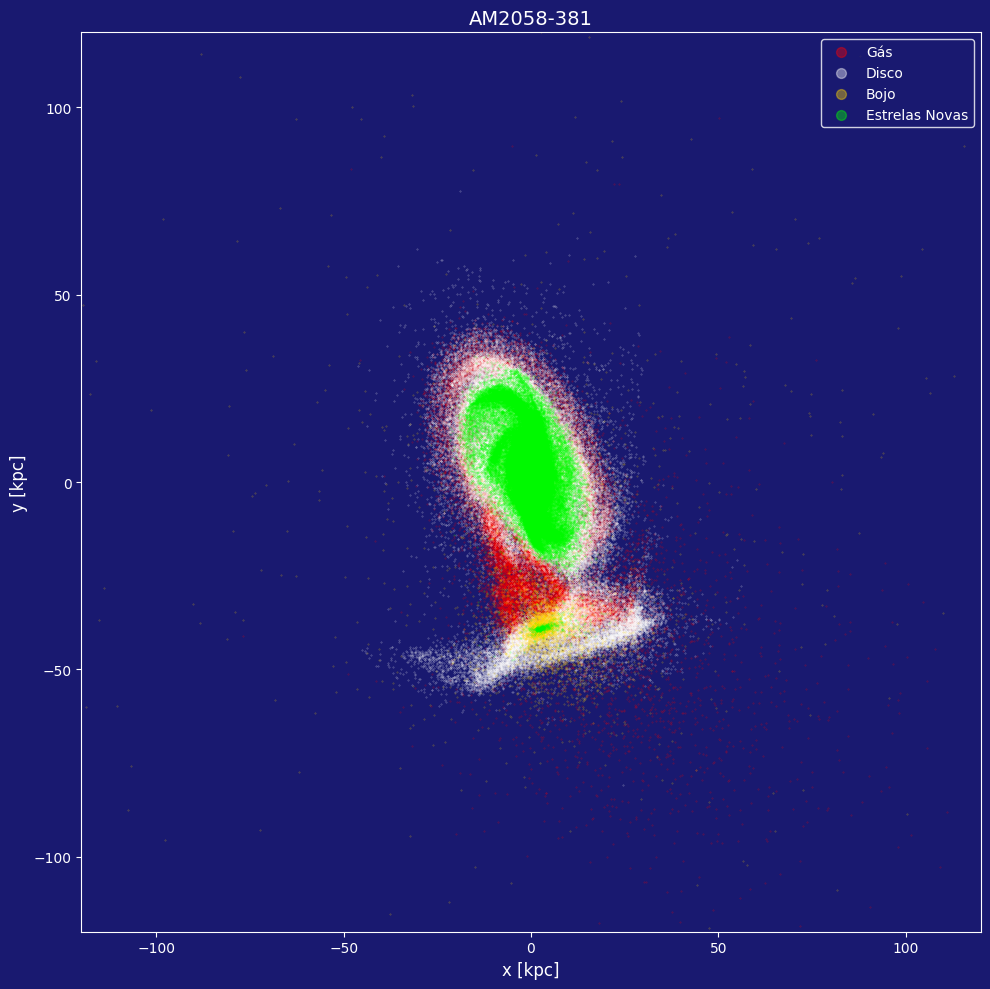

In [26]:
# ==============================================================================
# VISUALIZADOR DE GALÁXIA (FUNDO AZUL) - LEGENDA CORRIGIDA
# ==============================================================================

# --- 1. CONFIGURAÇÕES ---
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
limite_box = 120  # kpc

# Definição da cor do fundo
cor_fundo = 'midnightblue' 

# Configuração de Cores Claras para contraste com Fundo Azul
config_comps = [
    # Nome (unsio) | Cor (Clara)      | Tamanho | Alpha | Legenda
    ('gas',          'red',            0.1,    0.4,      'Gás'),
    ('disk',         'white',           0.1,    0.4,      'Disco'),
    ('bulge',        'gold',            0.1,    0.4,      'Bojo'),
    ('stars',        'lime',            0.1,    0.4,      'Estrelas Novas') 
]

# --- 2. PREPARAÇÃO DA FIGURA ---
fig, ax = plt.subplots(figsize=(10, 10)) 

# Aplicando a cor de fundo na figura e nos eixos
fig.patch.set_facecolor(cor_fundo)
ax.set_facecolor(cor_fundo)

print(f"Lendo snapshot: {simname}")
particulas_totais = 0

# --- 3. LOOP DE PLOTAGEM ---
for comp_nome, cor, tamanho, alpha, label_legenda in config_comps:
    try:
        uns = uns_in.CUNS_IN(simname, comp_nome)
        if uns.nextFrame():
            status, pos = uns.getData(comp_nome, "pos")
            if status:
                pos = pos.reshape(-1, 3)
                n_part = len(pos)
                particulas_totais += n_part
                
                print(f" -> Plotando {label_legenda}: {n_part} partículas...")
                x = pos[:, 0]
                y = pos[:, 1]
                
                # Plotagem
                ax.scatter(x, y, c=cor, s=tamanho, alpha=alpha, label=label_legenda, rasterized=True)
                
    except Exception as e:
        print(f" -> Erro ao ler {comp_nome}: {e}")

# --- 4. ESTÉTICA FINAL ---
# Títulos e Labels em Branco
ax.set_xlabel("x [kpc]", fontsize=12, color='white')
ax.set_ylabel("y [kpc]", fontsize=12, color='white')
ax.set_title(f"AM2058-381", fontsize=14, color='white')

# Ticks (tracinhos) em branco
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Bordas do gráfico em branco
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Limites e Proporção
ax.set_xlim(-limite_box, limite_box)
ax.set_ylim(-limite_box, limite_box)
ax.set_aspect('equal')

# --- LEGENDA (AJUSTADA) ---
leg = ax.legend(loc='upper right', frameon=True, facecolor=cor_fundo, edgecolor='white')

# 1. Ajustar cor do texto da legenda
for text in leg.get_texts():
    text.set_color("white")

# 2. AUMENTAR O TAMANHO DAS BOLINHAS NA LEGENDA
# Isso sobrescreve o tamanho 0.009 original apenas dentro da caixa da legenda
for handle in leg.legend_handles:
    handle.set_sizes([50]) # Tamanho visível (ex: 50)

plt.tight_layout()

# Salvar
nome_arquivo = "AM2058-381 Vis.png"
plt.savefig(nome_arquivo, dpi=300, facecolor=cor_fundo)
print(f"\nGráfico salvo como: {nome_arquivo}")

plt.show()

## Distância Projetada

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
 -> Gás: 84558 partículas.
 -> Disco: 220000 partículas.
 -> Bojo: 15000 partículas.
 -> Estrelas: 135442 partículas.
Localizando núcleos por densidade local...


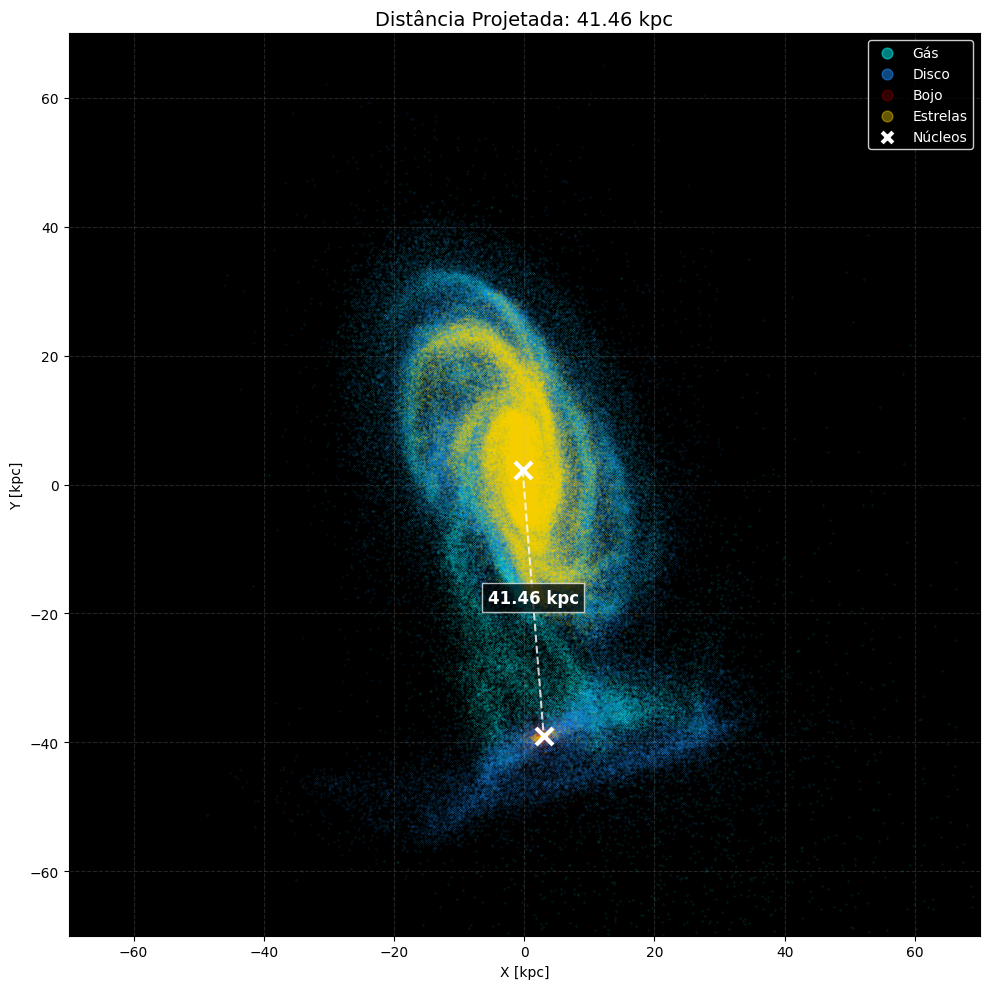

Sucesso! Distância calculada: 41.457 kpc


In [3]:
# ==============================================================================
# 1. CONFIGURAÇÕES E CAMINHOS
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
limite_box = 70  # Tamanho do campo de visão em kpc

# Definição das componentes e cores desejadas
config_comps = [
    {"name": "gas",   "color": "cyan",       "label": "Gás",      "size": 0.02, "alpha": 0.5},
    {"name": "disk",  "color": "dodgerblue", "label": "Disco",    "size": 0.02, "alpha": 0.5},
    {"name": "bulge", "color": "red",        "label": "Bojo",     "size": 0.01, "alpha": 0.2},
    {"name": "stars", "color": "gold",       "label": "Estrelas", "size": 0.04, "alpha": 0.4} # Estrelas novas
]

# ==============================================================================
# 2. LEITURA DO SNAPSHOT (UNSIO)
# ==============================================================================
print(f"Lendo snapshot: {simname}")
all_pos = []
all_mass = []
componentes_carregadas = []

for comp in config_comps:
    try:
        # Abre o snapshot apenas para a componente atual
        uns = uns_in.CUNS_IN(simname, comp["name"])
        if uns.nextFrame():
            status_p, p = uns.getData(comp["name"], "pos")
            status_m, m = uns.getData(comp["name"], "mass")
            
            if status_p and len(p) > 0:
                p = p.reshape(-1, 3)
                all_pos.append(p)
                all_mass.append(m)
                
                # Guarda dados para plotagem individual
                componentes_carregadas.append({
                    "pos": p,
                    "color": comp["color"],
                    "label": comp["label"],
                    "size": comp["size"],
                    "alpha": comp["alpha"]
                })
                print(f" -> {comp['label']}: {len(p)} partículas.")
    except Exception as e:
        print(f" -> Erro ao ler {comp['name']}: {e}")

if not all_pos:
    print("ERRO: Nenhuma partícula encontrada no snapshot!")
    exit()

# Combina todas as posições e massas para o cálculo do centro
pos_global = np.vstack(all_pos)
mass_global = np.concatenate(all_mass)

# ==============================================================================
# 3. CÁLCULO DOS CENTROS (DENSIDADE LOCAL + SHRINKING SPHERE)
# ==============================================================================
def shrinking_sphere(pos, mass, center_guess, r_ini=10.0, r_min=0.01):
    cm = center_guess
    r = r_ini
    while r > r_min:
        d2 = np.sum((pos - cm)**2, axis=1)
        mask = d2 < r**2
        if np.sum(mask) < 30: break
        cm = np.average(pos[mask], axis=0, weights=mass[mask])
        r *= 0.7
    return cm

print("Localizando núcleos por densidade local...")
tree = KDTree(pos_global)
# Contagem de vizinhos num raio de 2kpc para achar os núcleos densos
counts = tree.query_radius(pos_global, r=2.0, count_only=True)

# Centro A: Pico global de densidade
idx_A = np.argmax(counts)
provisorio_A = pos_global[idx_A]
cm_A = shrinking_sphere(pos_global, mass_global, provisorio_A)

# Centro B: Pico de densidade a pelo menos 15kpc de A
dist_de_A = np.sqrt(np.sum((pos_global - provisorio_A)**2, axis=1))
mask_longe = dist_de_A > 20.0

if np.any(mask_longe):
    idx_B = np.where(mask_longe)[0][np.argmax(counts[mask_longe])]
    provisorio_B = pos_global[idx_B]
    cm_B = shrinking_sphere(pos_global, mass_global, provisorio_B)
else:
    cm_B = cm_A # Caso as galáxias estejam fundidas

dist_2d = np.sqrt((cm_A[0]-cm_B[0])**2 + (cm_A[1]-cm_B[1])**2)

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
plt.figure(figsize=(10, 10))
plt.gca().set_facecolor('black')

# Plotar cada componente com sua respectiva cor
for comp in componentes_carregadas:
    plt.scatter(comp["pos"][:,0], comp["pos"][:,1], 
                s=comp["size"], c=comp["color"], alpha=comp["alpha"], 
                label=comp["label"], rasterized=True)

# Marcadores dos Centros e Linha de Distância
plt.scatter([cm_A[0], cm_B[0]], [cm_A[1], cm_B[1]], 
            c='white', marker='x', s=150, linewidth=3, zorder=10, label='Núcleos')

plt.plot([cm_A[0], cm_B[0]], [cm_A[1], cm_B[1]], 
         color='white', linestyle='--', linewidth=1.5, alpha=0.8)

# Texto da distância centralizado na linha
plt.text((cm_A[0]+cm_B[0])/2, (cm_A[1]+cm_B[1])/2, f"{dist_2d:.2f} kpc", 
         color='white', fontsize=12, fontweight='bold', ha='center',
         bbox=dict(facecolor='black', alpha=0.7, edgecolor='white'))

# Estética Final
plt.xlabel("X [kpc]", color='black')
plt.ylabel("Y [kpc]", color='black')
plt.title(f"Distância Projetada: {dist_2d:.2f} kpc", color='black', fontsize=14)
plt.xlim(-limite_box, limite_box)
plt.ylim(-limite_box, limite_box)
plt.grid(True, linestyle='--', alpha=0.2)

# Ajuste da Legenda
leg = plt.legend(loc='upper right', facecolor='black', edgecolor='white')
for text in leg.get_texts(): text.set_color("white")
for handle in leg.legend_handles: handle.set_sizes([60])

plt.tight_layout()
plt.savefig("Distância Projetada AM2058-381.png", dpi=300)
plt.show()

print(f"Sucesso! Distância calculada: {dist_2d:.3f} kpc")

## Mapas de Velocidade

Lendo snapshot para mapa de velocidade: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Identificando Galáxia A para calibração...
Velocidade Sistêmica calculada (Núcleo A): 14.24 km/s


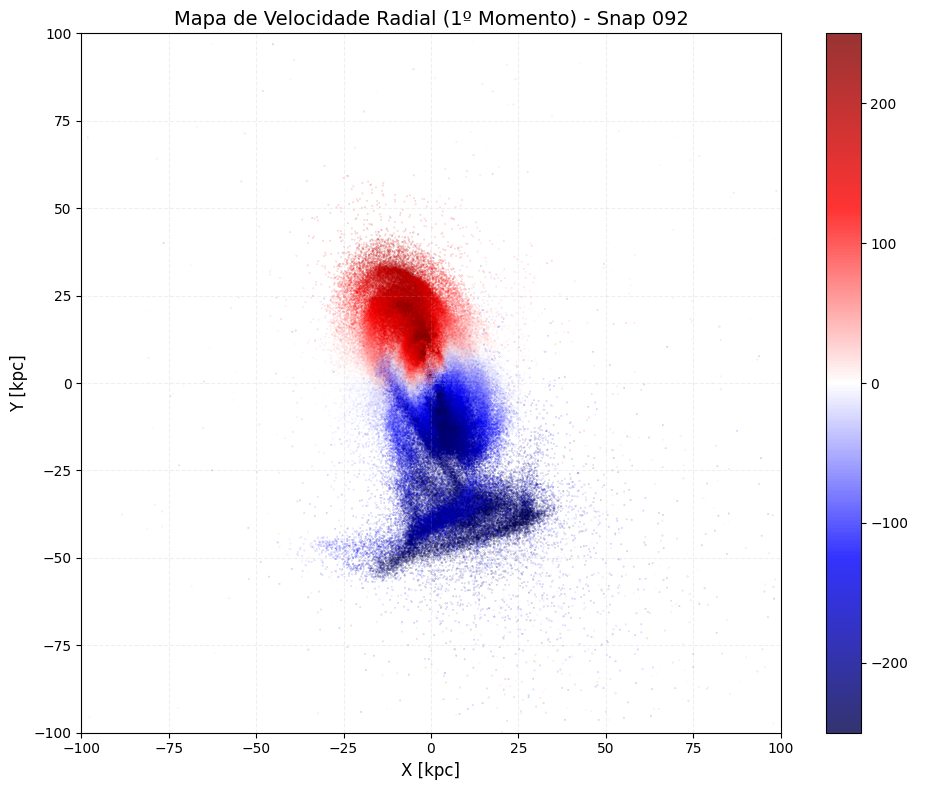

Mapa de velocidade gerado com sucesso!


In [4]:
# ==============================================================================
# 1. CONFIGURAÇÕES E LEITURA
# ==============================================================================
# Use o mesmo caminho da célula anterior
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_mapa = "gas,disk,bulge,stars"

print(f"Lendo snapshot para mapa de velocidade: {simname}")

try:
    uns = uns_in.CUNS_IN(simname, componentes_mapa)
    if not uns.nextFrame():
        raise ValueError("Não foi possível ler o frame.")

    # Coletar Posições, Velocidades e Massas
    status_p, pos = uns.getData(componentes_mapa, "pos")
    status_v, vel = uns.getData(componentes_mapa, "vel")
    status_m, mass = uns.getData(componentes_mapa, "mass")

    if not status_p or not status_v:
        raise ValueError("Erro ao extrair dados de posição ou velocidade.")

    # Reshape: pos e vel vêm como arrays planos (x1,y1,z1,x2,y2,z2...)
    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    
    x = pos[:, 0]
    y = pos[:, 1]
    vz = vel[:, 2] # Velocidade no eixo Z (Radial)

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 2. LOCALIZAÇÃO E CALIBRAÇÃO (GALÁXIA A)
# ==============================================================================
print("Identificando Galáxia A para calibração...")

# Usamos KDTree para achar o pico de densidade (Núcleo da A)
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# Selecionamos partículas próximas ao núcleo de A (raio de 5kpc) para a v_sistêmica
dist_sq = np.sum((pos - centro_A)**2, axis=1)
mask_nucleo_A = dist_sq < 5.0**2

v_sistemica = np.median(vz[mask_nucleo_A])
print(f"Velocidade Sistêmica calculada (Núcleo A): {v_sistemica:.2f} km/s")

# Correção da velocidade
vz_corrigido = vz - v_sistemica

# ==============================================================================
# 3. PLOTAGEM DO MAPA (1º MOMENTO)
# ==============================================================================
# Definir limites de cor baseados no desvio padrão da galáxia principal
std_vz = np.std(vz[mask_nucleo_A]) * 5 # Ajuste o multiplicador para o contraste ideal
limite_vel = 250 # Ou use algo fixo como 250 km/s para melhor visualização de fusões

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('white')

# Scatter plot colorido pela velocidade
# seismic é o mapa padrão: azul (aproximação), branco (zero), vermelho (afastamento)
sc = ax.scatter(x, y, c=vz_corrigido, s=0.01, cmap='seismic', 
                vmin=-limite_vel, vmax=limite_vel, alpha=0.8, rasterized=True)

# Barra de Cores
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Velocidade Radial ($V_z$) [km/s]', color='white', fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.add_lines(levels=[0], colors=['white'], linewidths=[1.5])

# Centralizar a visualização no sistema
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)

# Estética
ax.set_xlabel('X [kpc]', fontsize=12)
ax.set_ylabel('Y [kpc]', fontsize=12)
ax.set_title(f'Mapa de Velocidade Radial (1º Momento) - Snap {simname[-3:]}', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.savefig("Mapa_Velocidade_Snapshot150.png", dpi=300, bbox_inches='tight')
plt.show()

print("Mapa de velocidade gerado com sucesso!")

## Análises das PVRs

# AM2058A

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Localizando núcleo da Galáxia A por densidade...
Centro A: [-0.2809898  2.376389 ] | V_sist: 14.24 km/s


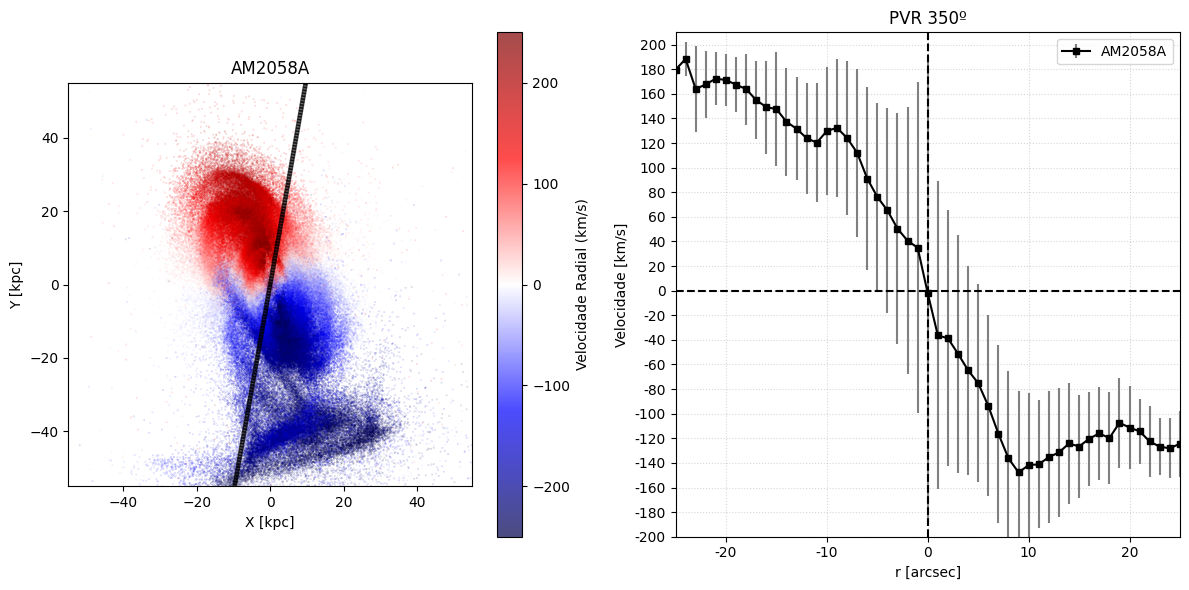

In [5]:
# ==============================================================================
# 1. CONFIGURAÇÕES E LEITURA DO SNAPSHOT
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_analise = "gas,disk,bulge,stars"

# Parâmetros Observacionais
PA_graus = 350
arcsec_to_kpc = 0.808          
step_arcsec = 1.0              
width_arcsec = 1.17            

# Conversão para KPC
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 2000

print(f"Lendo snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_analise)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    status_p, pos = uns.getData(componentes_analise, "pos")
    status_v, vel = uns.getData(componentes_analise, "vel")
    status_m, mass = uns.getData(componentes_analise, "mass")

    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    
    # Inversão da velocidade conforme padrão observacional
    vz_raw = vel[:, 2] 

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 2. LOCALIZAÇÃO E CENTRALIZAÇÃO (GALÁXIA A AUTOMÁTICA)
# ==============================================================================
print("Localizando núcleo da Galáxia A por densidade...")
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# Cálculo da Velocidade Sistêmica (V_sist) no núcleo
dist_sq = np.sum((pos - centro_A)**2, axis=1)
mask_nucleo = dist_sq < 5.0**2
v_sist = np.median(vz_raw[mask_nucleo])

# Centralização física e calibração de velocidade
x_cent = pos[:, 0] - centro_A[0]
y_cent = pos[:, 1] - centro_A[1]
vz_cent = vz_raw - v_sist

print(f"Centro A: {centro_A[:2]} | V_sist: {v_sist:.2f} km/s")

# ==============================================================================
# 3. ROTAÇÃO E BINAGEM (CÁLCULO)
# ==============================================================================
theta_cart_deg = 90 + PA_graus 
theta_rad = np.radians(theta_cart_deg)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

# Rotacionar Partículas
x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c

# Inversão para ordem física de leitura
x_rot = x_rot

# Filtra partículas na largura da fenda
mask_largura = np.abs(y_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

# Binagem
bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades, erros, posicoes_arcsec = [], [], []

for i in bins_indices:
    x_min = i * bin_size_kpc - (bin_size_kpc/2)
    x_max = i * bin_size_kpc + (bin_size_kpc/2)
    mask_bin = (x_slit >= x_min) & (x_slit < x_max)
    vz_bin = vz_slit[mask_bin]
    if len(vz_bin) > 3:
        velocidades.append(np.mean(vz_bin))
        erros.append(np.std(vz_bin))
        posicoes_arcsec.append(i * step_arcsec) 

# ==============================================================================
# 4. PLOTAGEM FINAL
# ==============================================================================
fig = plt.figure(figsize=(12, 6))

# --- GRÁFICO 1: MAPA EM KPC ---
ax1 = fig.add_subplot(121)
lim_cor = 250 # Limite fixo para facilitar comparação entre momentos
sc = ax1.scatter(x_cent, y_cent, s=0.01, c=vz_cent, cmap='seismic', 
                 vmin=-lim_cor, vmax=lim_cor, alpha=0.7, rasterized=True)

# Desenha fenda
for i in bins_indices:
    if abs(i) > 100: continue # Desenha apenas parte central para não poluir
    xc_rot_kpc = -(i * bin_size_kpc) 
    dx, dy = bin_size_kpc / 2, slit_width_kpc / 2
    corners_rot = np.array([[xc_rot_kpc-dx, -dy], [xc_rot_kpc+dx, -dy], [xc_rot_kpc+dx, dy], [xc_rot_kpc-dx, dy]])
    c_b, s_b = np.cos(theta_rad), np.sin(theta_rad)
    corners_screen = np.zeros_like(corners_rot)
    corners_screen[:, 0] = corners_rot[:, 0] * c_b - corners_rot[:, 1] * s_b
    corners_screen[:, 1] = corners_rot[:, 0] * s_b + corners_rot[:, 1] * c_b
    poly = Polygon(corners_screen, closed=True, edgecolor='black', facecolor='black', alpha=0.6)
    ax1.add_patch(poly)

ax1.set_xlim(-55, 55); ax1.set_ylim(-55, 55); ax1.set_aspect('equal')
ax1.set_title(f"AM2058A"); ax1.set_xlabel("X [kpc]"); ax1.set_ylabel("Y [kpc]")
plt.colorbar(sc, ax=ax1, label='Velocidade Radial (km/s)')

# --- GRÁFICO 2: PVR ---
ax2 = fig.add_subplot(122)
limit_x_min, limit_x_max = -25, 25
limit_y_min, limit_y_max = -210, 200
ax2.set_xlim(limit_x_min, limit_x_max); ax2.set_ylim(limit_y_min, limit_y_max)
ax2.errorbar(posicoes_arcsec, velocidades, yerr=erros, fmt='s-', markersize=4, color='black', ecolor='gray', label='AM2058A')
ax2.axhline(0, color='k', ls='--'); ax2.axvline(0, color='k', ls='--')
#ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{int(-y)}'))
ax2.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax2.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax2.set_xlabel("r [arcsec]"); ax2.set_ylabel("Velocidade [km/s]"); ax2.set_title(f"PVR {PA_graus}º")
ax2.grid(True, linestyle=':', alpha=0.5); ax2.legend()

plt.tight_layout()
plt.savefig(f"Medicao_AM2058A_PA{PA_graus}.png", dpi=300, bbox_inches='tight')
plt.show()

# AM2058B

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Identificando núcleos por densidade local...
Centro B: [  2.711389 -38.905807] | V_sist_B: 174.84 km/s


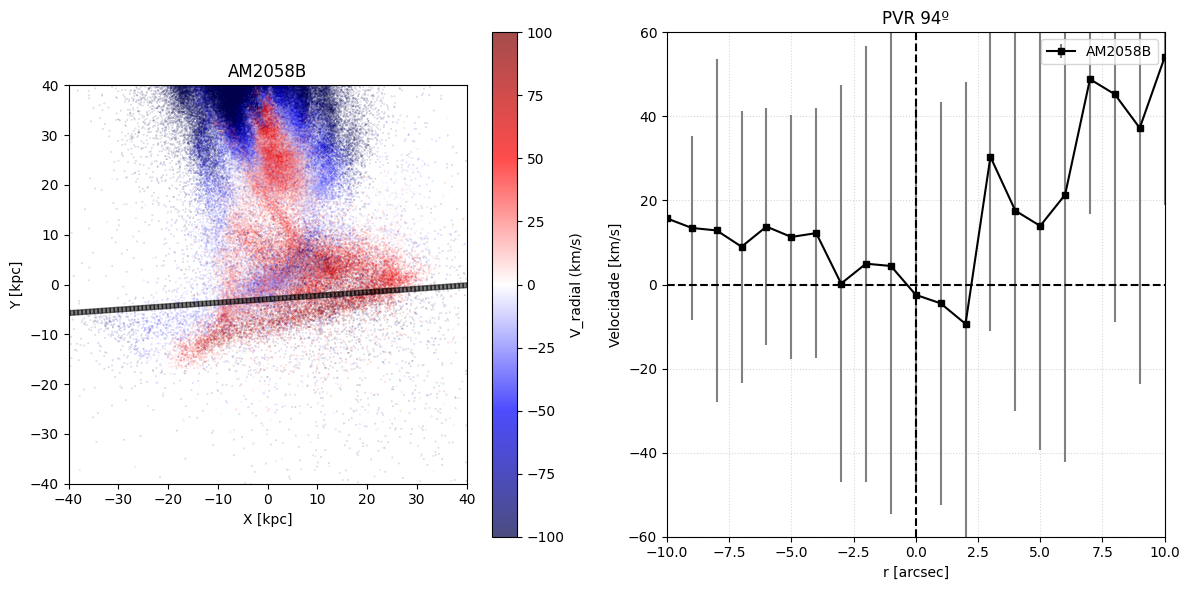

In [6]:
# ==============================================================================
# 1. CONFIGURAÇÕES E LEITURA DO SNAPSHOT
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_analise = "gas,disk,bulge,stars"

# Parâmetros Observacionais
PA_graus = 94
arcsec_to_kpc = 0.808          
step_arcsec = 1.0              
width_arcsec = 1.17            

# OFFSET DA FENDA (Físico)
offset_leste_arcsec = 1.0  
x_offset_kpc = -offset_leste_arcsec * arcsec_to_kpc 
y_offset_kpc = -3.0 

# Configurações de Binagem
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 200 # Aumentado para garantir fenda comprida

print(f"Lendo snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_analise)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    # Dados brutos
    status_p, pos_raw = uns.getData(componentes_analise, "pos")
    status_v, vel_raw = uns.getData(componentes_analise, "vel")
    status_m, mass_raw = uns.getData(componentes_analise, "mass")

    pos_raw = pos_raw.reshape(-1, 3)
    vel_raw = vel_raw.reshape(-1, 3)
    vz_raw = -vel_raw[:, 2] # Inversão observacional padrão

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 2. LOCALIZAÇÃO AUTOMÁTICA DA GALÁXIA B
# ==============================================================================
print("Identificando núcleos por densidade local...")
tree = KDTree(pos_raw)
counts = tree.query_radius(pos_raw, r=2.0, count_only=True)

# Núcleo A (Maior Densidade Global)
idx_A = np.argmax(counts)
centro_A = pos_raw[idx_A]

# Núcleo B (Maior Densidade longe de A)
dist_de_A = np.sqrt(np.sum((pos_raw - centro_A)**2, axis=1))
mask_longe_de_A = dist_de_A > 20.0 # Considera B como algo a > 20kpc de A

if np.any(mask_longe_de_A):
    idx_B = np.where(mask_longe_de_A)[0][np.argmax(counts[mask_longe_de_A])]
    centro_B = pos_raw[idx_B]
else:
    print("Aviso: Galáxia B não encontrada ou fundida. Usando centro global.")
    centro_B = centro_A

# Centralização na Galáxia B
dist_sq_B = np.sum((pos_raw - centro_B)**2, axis=1)
mask_nucleo_B = dist_sq_B < 3.0**2
v_sist_B = np.median(vz_raw[mask_nucleo_B])

x_cent = pos_raw[:, 0] - centro_B[0]
y_cent = pos_raw[:, 1] - centro_B[1]
vz_cent = vz_raw - v_sist_B

print(f"Centro B: {centro_B[:2]} | V_sist_B: {v_sist_B:.2f} km/s")

# ==============================================================================
# 3. ROTAÇÃO E CÁLCULO DA PVR (FENDA)
# ==============================================================================
theta_rad = np.radians(90 + PA_graus)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

# Rotacionar posições
x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c

# Inversão física de leitura
x_rot = -x_rot

# Aplicação do Offset na fenda
# A fenda é centrada em Y = y_slit_center_rot em vez de zero
y_slit_center_rot = x_offset_kpc * s + y_offset_kpc * c

mask_largura = np.abs(y_rot - y_slit_center_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

# Binagem
bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades, erros, posicoes_arcsec = [], [], []

for i in bins_indices:
    x_min = i * bin_size_kpc - (bin_size_kpc/2)
    x_max = i * bin_size_kpc + (bin_size_kpc/2)
    mask_bin = (x_slit >= x_min) & (x_slit < x_max)
    vz_bin = vz_slit[mask_bin]
    if len(vz_bin) > 3:
        velocidades.append(np.mean(vz_bin))
        erros.append(np.std(vz_bin))
        posicoes_arcsec.append(i * step_arcsec) 

# ==============================================================================
# 4. PLOTAGEM FINAL
# ==============================================================================
fig = plt.figure(figsize=(12, 6))

# --- MAPA À ESQUERDA ---
ax1 = fig.add_subplot(121)
ax1.set_facecolor('white')
sc = ax1.scatter(x_cent, y_cent, s=0.01, c=vz_cent, cmap='seismic', 
                 vmin=-100, vmax=100, alpha=0.7, rasterized=True)

# Desenha fenda longa
for i in bins_indices:
    if abs(i) > 100: continue 
    xc_rot_kpc = -(i * bin_size_kpc)
    yc_rot_kpc = y_slit_center_rot
    dx, dy = bin_size_kpc / 2, slit_width_kpc / 2
    corners_rot = np.array([[xc_rot_kpc-dx, yc_rot_kpc-dy], [xc_rot_kpc+dx, yc_rot_kpc-dy], 
                            [xc_rot_kpc+dx, yc_rot_kpc+dy], [xc_rot_kpc-dx, yc_rot_kpc+dy]])
    c_b, s_b = np.cos(theta_rad), np.sin(theta_rad)
    corners_scr = np.zeros_like(corners_rot)
    corners_scr[:,0] = corners_rot[:,0]*c_b - corners_rot[:,1]*s_b
    corners_scr[:,1] = corners_rot[:,0]*s_b + corners_rot[:,1]*c_b
    ax1.add_patch(Polygon(corners_scr, closed=True, edgecolor='black', facecolor='black', alpha=0.5))

ax1.set_xlim(-40, 40); ax1.set_ylim(-40, 40); ax1.set_aspect('equal')
ax1.set_title(f"AM2058B"); ax1.set_xlabel("X [kpc]"); ax1.set_ylabel("Y [kpc]")
plt.colorbar(sc, ax=ax1, label='V_radial (km/s)')

# --- PVR À DIREITA ---
ax2 = fig.add_subplot(122)
limit_x_min, limit_x_max = -10, 10
limit_y_min, limit_y_max = -60, 60
ax2.set_xlim(limit_x_min, limit_x_max); ax2.set_ylim(limit_y_min, limit_y_max)
ax2.errorbar(posicoes_arcsec, velocidades, yerr=erros, fmt='s-', markersize=4, color='black', ecolor='gray', label='AM2058B')
ax2.axhline(0, color='k', ls='--'); ax2.axvline(0, color='k', ls='--')
#ax2.invert_xaxis()
ax2.set_xlabel("r [arcsec]"); ax2.set_ylabel("Velocidade [km/s]"); ax2.set_title(f"PVR {PA_graus}º")
ax2.grid(True, linestyle=':', alpha=0.5); ax2.legend()

plt.tight_layout()
plt.savefig("AM2058B_PVR_94º.png", dpi=300)
plt.show()

## Comparação do Trabalho Observacional e a Simulação

# AM2058A

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Identificando núcleo da Galáxia A para calibração...


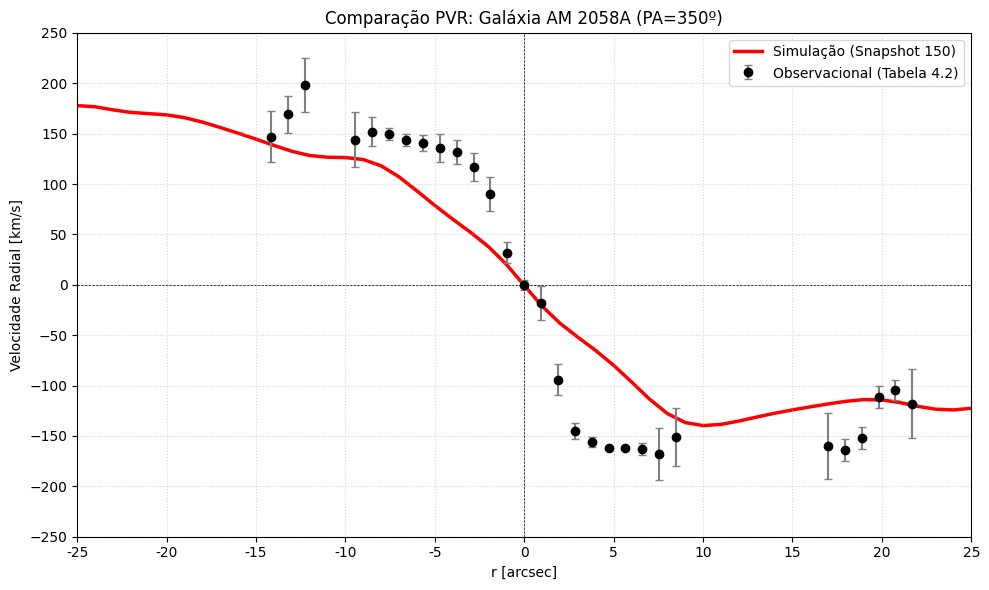

In [7]:
# ==============================================================================
# 1. DADOS OBSERVACIONAIS (TABELA 4.2 - AM 2058A)
# ==============================================================================
r_obs = np.array([-21.71, -20.76, -19.82, -18.87, -17.93, -16.99, -8.49, -7.55, -6.61, 
                  -5.66, -4.72, -3.77, -2.83, -1.89, -0.94, 0.0, 0.94, 1.89, 2.83, 
                  3.77, 4.72, 5.66, 6.61, 7.55, 8.49, 9.44, 12.27, 13.21, 14.16])

v_obs = np.array([-118, -104, -111, -152, -164, -160, -151, -168, -163, -162, -162, 
                  -156, -145, -94, -18, 0, 32, 90, 117, 132, 136, 141, 144, 150, 
                  152, 144, 198, 169, 147])

e_obs = np.array([34, 10, 11, 11, 11, 33, 29, 26, 6, 2, 2, 5, 8, 15, 17, 5, 10, 
                  17, 14, 12, 14, 8, 6, 6, 14, 27, 27, 18, 25])

# ==============================================================================
# 2. CONFIGURAÇÕES DA SIMULAÇÃO (LEITURA SNAPSHOT)
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_pvr = "gas,disk,bulge,stars"

# Parâmetros Observacionais
PA_graus = 350  # Ângulo de Posição
arcsec_to_kpc = 0.808
step_arcsec = 1.0  # Resolução da fenda
width_arcsec = 1.17

# Conversões Físicas
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 30 

print(f"Lendo snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_pvr)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    status_p, pos = uns.getData(componentes_pvr, "pos")
    status_v, vel = uns.getData(componentes_pvr, "vel")
    
    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    vz_raw = -vel[:, 2] # Inversão padrão para sentido observacional

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 3. LOCALIZAÇÃO E CALIBRAÇÃO (NÚCLEO A)
# ==============================================================================
print("Identificando núcleo da Galáxia A para calibração...")
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# Velocidade Sistêmica no núcleo (raio 5kpc)
dist_sq = np.sum((pos - centro_A)**2, axis=1)
mask_nucleo = dist_sq < 5.0**2
v_sist = np.median(vz_raw[mask_nucleo])

# Centralização
x_cent = pos[:, 0] - centro_A[0]
y_cent = pos[:, 1] - centro_A[1]
vz_cent = vz_raw - v_sist

# ==============================================================================
# 4. ROTAÇÃO E BINAGEM (CÁLCULO DA FENDA)
# ==============================================================================
theta_rad = np.radians(90 + PA_graus)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

# Rotacionar Partículas
x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c

# Inversão Eixo X (Ordem de leitura da fenda)
x_rot = -x_rot

# Filtro de fenda
mask_largura = np.abs(y_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

# Binagem
bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades_sim, posicoes_sim = [], []

for i in bins_indices:
    x_min = i * bin_size_kpc - (bin_size_kpc/2)
    x_max = i * bin_size_kpc + (bin_size_kpc/2)
    mask_bin = (x_slit >= x_min) & (x_slit < x_max)
    vz_bin = vz_slit[mask_bin]
    if len(vz_bin) > 3:
        velocidades_sim.append(np.mean(vz_bin))
        posicoes_sim.append(i * step_arcsec)

# Suavização
velocidades_sim_smooth = gaussian_filter1d(velocidades_sim, sigma=1.5)

# ==============================================================================
# 5. PLOTAGEM COMPARATIVA
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Simulação
ax.plot(posicoes_sim, velocidades_sim_smooth, color='red', linewidth=2.5, 
        label='Simulação (Snapshot 150)', zorder=1)

# 2. Observacional
ax.errorbar(r_obs, v_obs, yerr=e_obs, fmt='o', color='black', 
            ecolor='gray', elinewidth=1.5, capsize=3, markersize=6, 
            label='Observacional (Tabela 4.2)', zorder=2)

ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax.axvline(0, color='k', linestyle='--', linewidth=0.5)

ax.set_xlabel("r [arcsec]")
ax.set_ylabel("Velocidade Radial [km/s]")
ax.set_title(f"Comparação PVR: Galáxia AM 2058A (PA={PA_graus}º)")

ax.invert_xaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(-x)}'))
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.set_xlim(25, -25) 
ax.set_ylim(-250, 250)

ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(f"Comparacao_Sim_Obs_PA{PA_graus}.png", dpi=300)
plt.show()

# AM2058B

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Localizando núcleos por densidade local...


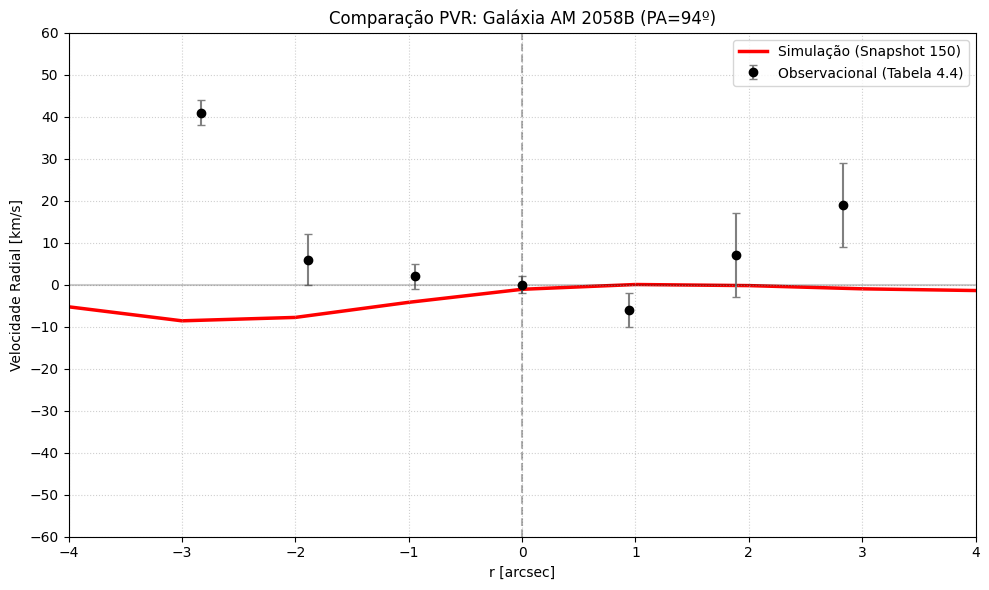

In [8]:
# ==============================================================================
# 1. DADOS OBSERVACIONAIS (TABELA 4.4 - AM 2058B - PA 94)
# ==============================================================================
r_obs = np.array([-2.83, -1.89, -0.94, 0.0, 0.94, 1.89, 2.83])
v_obs = np.array([41.0, 6.0, 2.0, 0.0, -6.0, 7.0, 19.0])
e_obs = np.array([3.0, 6.0, 3.0, 2.0, 4.0, 10.0, 10.0])

# ==============================================================================
# 2. CONFIGURAÇÕES DA SIMULAÇÃO (LEITURA SNAPSHOT)
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_analise = "gas,disk,bulge,stars"

# Parâmetros Observacionais
PA_graus = 94
arcsec_to_kpc = 0.808
step_arcsec = 1.0  
width_arcsec = 1.17

# Conversões Físicas
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 10 # Fenda curta para a galáxia B

print(f"Lendo snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_analise)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    status_p, pos = uns.getData(componentes_analise, "pos")
    status_v, vel = uns.getData(componentes_analise, "vel")
    
    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    vz_raw = -vel[:, 2] # Inversão padrão observacional

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 3. LOCALIZAÇÃO AUTOMÁTICA DA GALÁXIA B
# ==============================================================================
print("Localizando núcleos por densidade local...")
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)

# Núcleo A (Global)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# Núcleo B (Densa e longe de A)
dist_de_A = np.sqrt(np.sum((pos - centro_A)**2, axis=1))
mask_longe = dist_de_A > 20.0
if np.any(mask_longe):
    idx_B = np.where(mask_longe)[0][np.argmax(counts[mask_longe])]
    centro_B = pos[idx_B]
else:
    centro_B = centro_A

# Calibração na Galáxia B
dist_sq_B = np.sum((pos - centro_B)**2, axis=1)
mask_nucleo_B = dist_sq_B < 3.0**2
v_sist_B = np.median(vz_raw[mask_nucleo_B])

# Centralização
x_cent = pos[:, 0] - centro_B[0]
y_cent = pos[:, 1] - centro_B[1]
vz_cent = vz_raw - v_sist_B

# ==============================================================================
# 4. ROTAÇÃO E BINAGEM (CÁLCULO DA PVR)
# ==============================================================================
theta_rad = np.radians(90 + PA_graus)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c
x_rot = -x_rot # Inversão para ordem de leitura

# Filtro de fenda centrada em B
mask_largura = np.abs(y_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades_sim, posicoes_sim = [], []

for i in bins_indices:
    x_min = i * bin_size_kpc - (bin_size_kpc/2)
    x_max = i * bin_size_kpc + (bin_size_kpc/2)
    mask_bin = (x_slit >= x_min) & (x_slit < x_max)
    vz_bin = vz_slit[mask_bin]
    if len(vz_bin) > 3:
        velocidades_sim.append(np.mean(vz_bin))
        posicoes_sim.append(i * step_arcsec)

# Suavização
velocidades_sim_smooth = gaussian_filter1d(velocidades_sim, sigma=1.2) if velocidades_sim else []

# ==============================================================================
# 5. PLOTAGEM COMPARATIVA
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Simulação
if len(posicoes_sim) > 0:
    ax.plot(posicoes_sim, velocidades_sim_smooth, color='red', linewidth=2.5, 
            label='Simulação (Snapshot 150)', zorder=1)

# 2. Observacional
ax.errorbar(r_obs, v_obs, yerr=e_obs, fmt='o', color='black', 
            ecolor='gray', elinewidth=1.5, capsize=3, markersize=6, 
            label='Observacional (Tabela 4.4)', zorder=2)

ax.axhline(0, color='k', ls='-', alpha=0.2)
ax.axvline(0, color='k', ls='--', alpha=0.3)

ax.set_xlabel("r [arcsec]")
ax.set_ylabel("Velocidade Radial [km/s]")
ax.set_title(f"Comparação PVR: Galáxia AM 2058B (PA={PA_graus}º)")

ax.set_xlim(-4, 4)
ax.set_ylim(-60, 60)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))

ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f"Comparacao_B_PA{PA_graus}.png", dpi=300)
plt.show()

# Comparação Ponto a Ponto AM2058A

Lendo snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
Localizando núcleo da Galáxia A por densidade...
Centro A: [-0.2809898  2.376389 ] | V_sist: -14.24 km/s


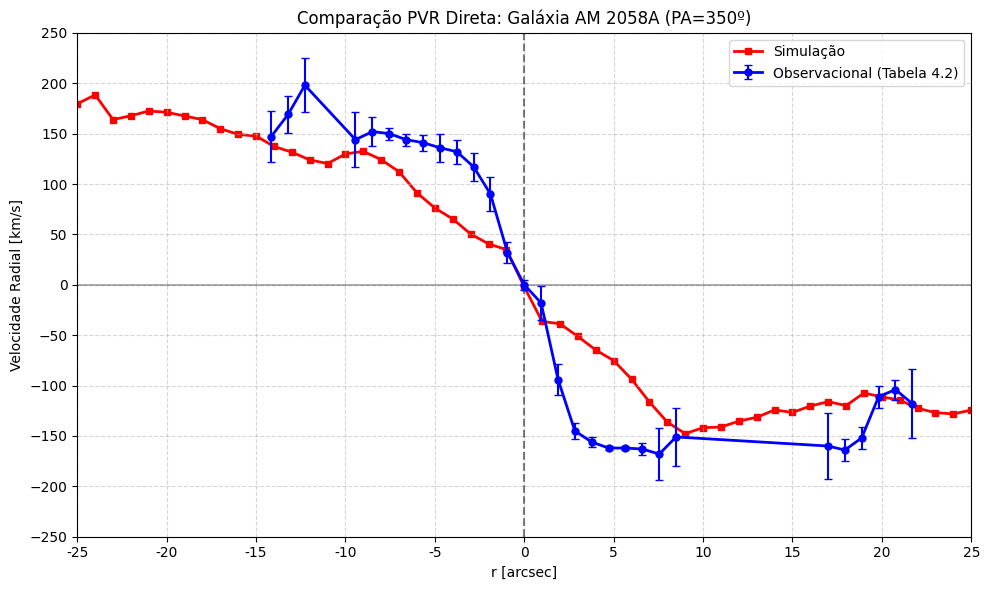

In [9]:
# ==============================================================================
# 1. DADOS OBSERVACIONAIS (TABELA 4.2 - AM 2058A - PA 350)
# ==============================================================================
r_obs = np.array([-21.71, -20.76, -19.82, -18.87, -17.93, -16.99, -8.49, -7.55, -6.61, 
                  -5.66, -4.72, -3.77, -2.83, -1.89, -0.94, 0.0, 0.94, 1.89, 2.83, 
                  3.77, 4.72, 5.66, 6.61, 7.55, 8.49, 9.44, 12.27, 13.21, 14.16])

v_obs = np.array([-118, -104, -111, -152, -164, -160, -151, -168, -163, -162, -162, 
                  -156, -145, -94, -18, 0, 32, 90, 117, 132, 136, 141, 144, 150, 
                  152, 144, 198, 169, 147])

e_obs = np.array([34, 10, 11, 11, 11, 33, 29, 26, 6, 2, 2, 5, 8, 15, 17, 5, 10, 
                  17, 14, 12, 14, 8, 6, 6, 14, 27, 27, 18, 25])

# ==============================================================================
# 2. CONFIGURAÇÕES DA SIMULAÇÃO E LEITURA
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_analise = "gas,disk,bulge,stars"

# Parâmetros
PA_graus = 350
arcsec_to_kpc = 0.808
step_arcsec = 1.0  
width_arcsec = 1.17

# Conversões
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 30 # Galáxia A é grande, precisamos de mais bins

print(f"Lendo snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_analise)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    status_p, pos = uns.getData(componentes_analise, "pos")
    status_v, vel = uns.getData(componentes_analise, "vel")

    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    
    # Inversão da velocidade conforme padrão observacional
    vz_raw = -vel[:, 2] 

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 3. LOCALIZAÇÃO E CENTRALIZAÇÃO (MÉTODO DA DENSIDADE)
# ==============================================================================
print("Localizando núcleo da Galáxia A por densidade...")
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# Cálculo da Velocidade Sistêmica (V_sist) no núcleo
dist_sq = np.sum((pos - centro_A)**2, axis=1)
mask_nucleo = dist_sq < 5.0**2
v_sist = np.median(vz_raw[mask_nucleo])

print(f"Centro A: {centro_A[:2]} | V_sist: {v_sist:.2f} km/s")

# Centralização física e calibração de velocidade
x_cent = pos[:, 0] - centro_A[0]
y_cent = pos[:, 1] - centro_A[1]
vz_cent = vz_raw - v_sist

# ==============================================================================
# 4. ROTAÇÃO E BINAGEM (CÁLCULO DO PVR)
# ==============================================================================
# Rotação (PA=350)
theta_cart_deg = 90 + PA_graus 
theta_rad = np.radians(theta_cart_deg)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

# Rotacionar e Inverter Eixo de Leitura
x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c
x_rot = -x_rot

# Filtro da fenda
mask_largura = np.abs(y_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

# Binagem
bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades_sim, posicoes_sim = [], []

for i in bins_indices:
    x_min_kpc = i * bin_size_kpc - (bin_size_kpc/2)
    x_max_kpc = i * bin_size_kpc + (bin_size_kpc/2)
    
    mask_bin = (x_slit >= x_min_kpc) & (x_slit < x_max_kpc)
    vz_bin = vz_slit[mask_bin]
    
    if len(vz_bin) > 3:
        velocidades_sim.append(np.mean(vz_bin))
        posicoes_sim.append(i * step_arcsec) 

# ==============================================================================
# 5. PLOTAGEM COMPARATIVA (DADOS PUROS)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Simulação (Vermelho) - Linha sólida com quadrados
if len(posicoes_sim) > 0:
    ax.plot(posicoes_sim, velocidades_sim, color='red', marker='s', markersize=4, 
            linestyle='-', linewidth=2, label='Simulação', zorder=1)

# 2. Observacional (Azul) - Linha sólida com círculos e barras de erro
ax.errorbar(r_obs, v_obs, yerr=e_obs, fmt='o-', color='blue', 
            ecolor='blue', elinewidth=1.5, capsize=3, markersize=5, 
            linewidth=2, label='Observacional (Tabela 4.2)', zorder=2)

# Linhas de referência
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)

# Limites (ajustados para AM 2058A que é maior)
ax.set_xlim(-25, 25)
ax.set_ylim(-250, 250)

# Labels e Títulos
ax.set_xlabel("r [arcsec]")
ax.set_ylabel("Velocidade Radial [km/s]")
ax.set_title(f"Comparação PVR Direta: Galáxia AM 2058A (PA={PA_graus}º)")

# Inversão Visual do Eixo X e Formatação dos Labels
ax.invert_xaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(-x)}'))

# Ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))

ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"Ponto a Ponto AM2058A", dpi=300)
plt.show()

# AM2058B

A ler snapshot: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092
A localizar núcleos por densidade...
Centro B: [  2.711389 -38.905807] | V_sist B: 174.90 km/s


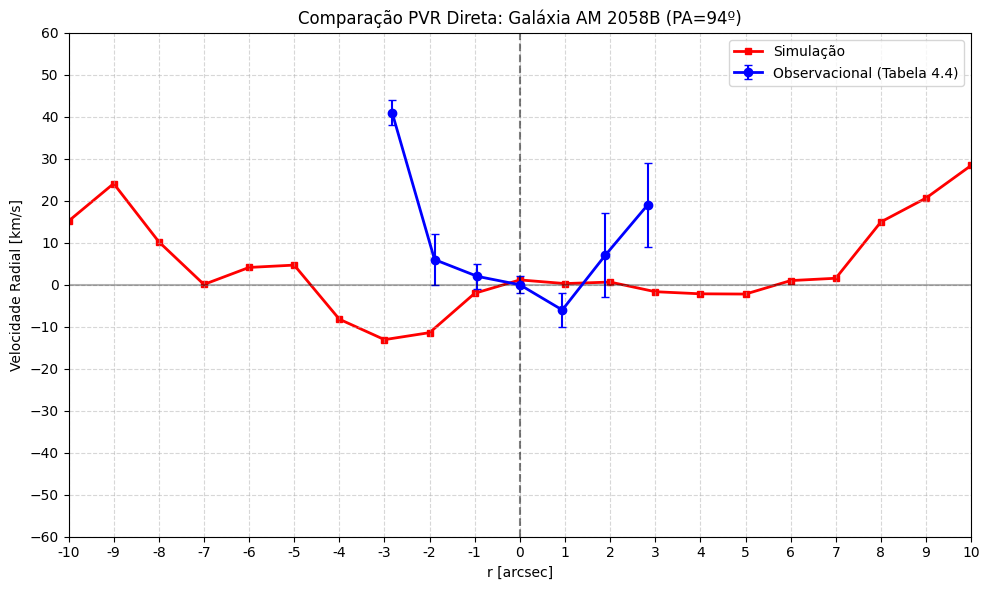

In [10]:
# ==============================================================================
# 1. DADOS OBSERVACIONAIS (TABELA 4.4 - AM 2058B - PA 94)
# ==============================================================================
# Dados extraídos do PDF
r_obs = np.array([-2.83, -1.89, -0.94, 0.0, 0.94, 1.89, 2.83])
v_obs = np.array([41.0, 6.0, 2.0, 0.0, -6.0, 7.0, 19.0])
e_obs = np.array([3.0, 6.0, 3.0, 2.0, 4.0, 10.0, 10.0])

# ==============================================================================
# 2. CONFIGURAÇÕES DA SIMULAÇÃO E LEITURA
# ==============================================================================
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092"
componentes_analise = "gas,disk,bulge,stars"

# Parâmetros Observacionais
PA_graus = 94
arcsec_to_kpc = 0.808
step_arcsec = 1.0  
width_arcsec = 1.17

# Conversões Físicas
bin_size_kpc = step_arcsec * arcsec_to_kpc
slit_width_kpc = width_arcsec * arcsec_to_kpc
n_bins_lado = 10 

print(f"A ler snapshot: {simname}")
try:
    uns = uns_in.CUNS_IN(simname, componentes_analise)
    if not uns.nextFrame(): raise ValueError("Erro ao ler frame.")

    status_p, pos = uns.getData(componentes_analise, "pos")
    status_v, vel = uns.getData(componentes_analise, "vel")

    pos = pos.reshape(-1, 3)
    vel = vel.reshape(-1, 3)
    
    # Inversão Velocidade (Simulação para Observacional)
    vz_raw = -vel[:, 2] 

except Exception as e:
    print(f"ERRO: {e}")
    exit()

# ==============================================================================
# 3. LOCALIZAÇÃO E CENTRALIZAÇÃO (MÉTODO DA DENSIDADE PARA A GALÁXIA B)
# ==============================================================================
print("A localizar núcleos por densidade...")
tree = KDTree(pos)
counts = tree.query_radius(pos, r=2.0, count_only=True)

# 1º Passo: Encontrar Galáxia A (pico máximo global)
idx_A = np.argmax(counts)
centro_A = pos[idx_A]

# 2º Passo: Encontrar Galáxia B (pico máximo excluindo a região da Galáxia A)
dist_sq_to_A = np.sum((pos - centro_A)**2, axis=1)
mask_fora_A = dist_sq_to_A > 20.0**2  # Ignora 20 kpc ao redor de A

idx_B_masked = np.argmax(counts[mask_fora_A])
centro_B = pos[mask_fora_A][idx_B_masked]

# Cálculo da Velocidade Sistêmica (V_sist) no núcleo da Galáxia B
dist_sq_to_B = np.sum((pos - centro_B)**2, axis=1)
mask_nucleo_B = dist_sq_to_B < 5.0**2
v_sist = np.median(vz_raw[mask_nucleo_B])

print(f"Centro B: {centro_B[:2]} | V_sist B: {v_sist:.2f} km/s")

# Centralização física e calibração de velocidade na Galáxia B
x_cent = pos[:, 0] - centro_B[0]
y_cent = pos[:, 1] - centro_B[1]
vz_cent = vz_raw - v_sist

# ==============================================================================
# 4. ROTAÇÃO E BINAGEM (CÁLCULO DO PVR)
# ==============================================================================
# Rotação (PA=94)
theta_cart_deg = 90 + PA_graus 
theta_rad = np.radians(theta_cart_deg)
c, s = np.cos(-theta_rad), np.sin(-theta_rad)

# Rotacionar e Inverter Eixo de Leitura
x_rot = x_cent * c - y_cent * s
y_rot = x_cent * s + y_cent * c
x_rot = -x_rot

# Filtro da fenda
mask_largura = np.abs(y_rot) <= (slit_width_kpc / 2.0)
x_slit = x_rot[mask_largura]
vz_slit = vz_cent[mask_largura]

# Binagem Simulação
bins_indices = np.arange(-n_bins_lado, n_bins_lado + 1)
velocidades_sim, posicoes_sim = [], []

for i in bins_indices:
    x_min_kpc = i * bin_size_kpc - (bin_size_kpc/2)
    x_max_kpc = i * bin_size_kpc + (bin_size_kpc/2)
    
    mask_bin = (x_slit >= x_min_kpc) & (x_slit < x_max_kpc)
    vz_bin = vz_slit[mask_bin]
    
    if len(vz_bin) > 3:
        velocidades_sim.append(np.mean(vz_bin))
        posicoes_sim.append(i * step_arcsec) 

# ==============================================================================
# 5. PLOTAGEM COMPARATIVA (DADOS PUROS)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Simulação (Vermelho) - Linha conectada com pontos
if len(posicoes_sim) > 0:
    ax.plot(posicoes_sim, velocidades_sim, color='red', marker='s', markersize=5, 
            linestyle='-', linewidth=2, label='Simulação', zorder=1)

# 2. Observacional (Azul) - Linha conectada com pontos e erro
ax.errorbar(r_obs, v_obs, yerr=e_obs, fmt='o-', color='blue', 
            ecolor='blue', elinewidth=1.5, capsize=3, markersize=6, 
            linewidth=2, label='Observacional (Tabela 4.4)', zorder=2)

# Linhas de referência
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.5)

# Limites
ax.set_xlim(-10, 10)
ax.set_ylim(-60, 60)

# Labels e Títulos
ax.set_xlabel("r [arcsec]")
ax.set_ylabel("Velocidade Radial [km/s]")
ax.set_title(f"Comparação PVR Direta: Galáxia AM 2058B (PA={PA_graus}º)")

# Formatação dos Labels
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}'))
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Comparacao_AM2058B_PA94_Sim_e_Obs.png", dpi=300, bbox_inches='tight')
plt.show()

## Curva de Rotação Final

--- Lendo dados globais de: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092 ---
   -> Halo: 560000 partículas
   -> Disk: 220000 partículas
   -> Bulge: 15000 partículas
   -> Gas: 84558 partículas
   -> Stars: 135442 partículas

--- Localizando Centros de Massa por Densidade ---
Centro A: [-0.23280165  2.2283533   3.2041264 ]
Centro B: [  2.651015 -38.926365 -22.957077]
Distância entre centros: 48.85 kpc

Calculando curvas de rotação...
Salvo: Curva_Rotacao_AM2058A.png
Salvo: Curva_Rotacao_AM2058B.png


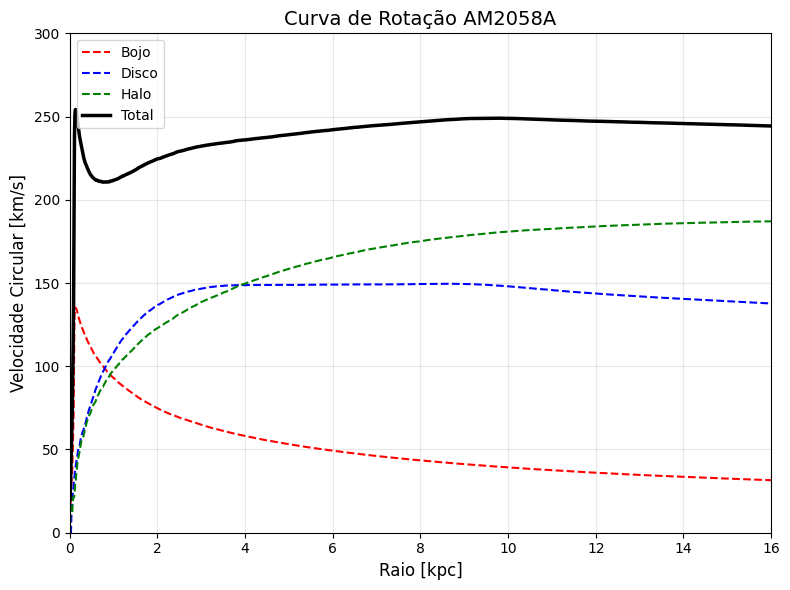

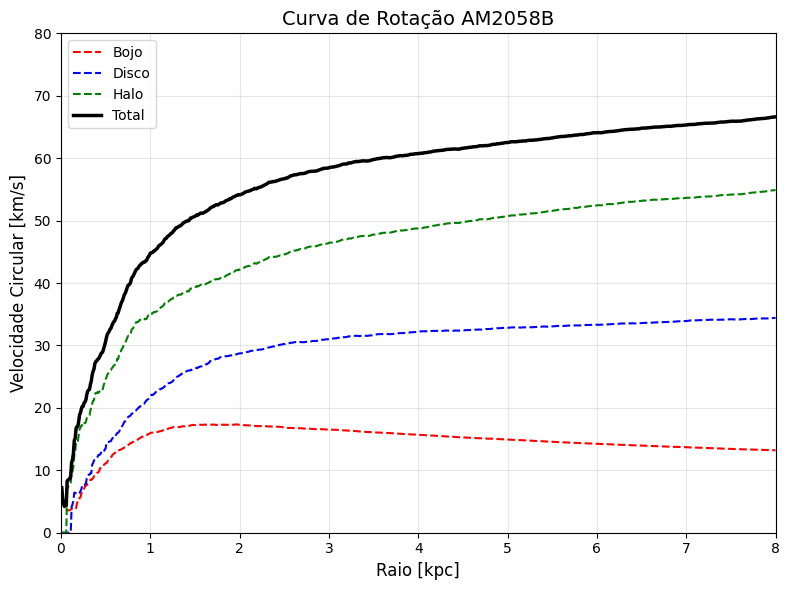

In [19]:
# ==============================================================================
# 1. CONFIGURAÇÕES ---
# ==============================================================================
# G em (km/s)^2 * kpc / (10^10 M_sol)
G_gadget = 43009.1 
# CONFIRME SE O CAMINHO E O NÚMERO DO SNAPSHOT ESTÃO CORRETOS
simname = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_092" 

# Componentes
comps_map = {"halo": "Halo", "disk": "Disco", "bulge": "Bojo", "gas": "Gás", "stars": "Estrelas"}
cores = {'halo': 'green', 'disk': 'blue', 'bulge': 'red', 'gas': 'cyan', 'stars': 'orange', 'total': 'black'}

# ==============================================================================
# 2. CARREGAR TUDO (GLOBAL) ---
# ==============================================================================
print(f"--- Lendo dados globais de: {simname} ---")

dados_globais = {}

# Mapeamento interno do unsio para os tipos de partículas
types_unsio = {"gas": "gas", "halo": "halo", "disk": "disk", "bulge": "bulge", "stars": "stars"}

for k in comps_map.keys():
    try:
        # Tenta carregar. Se falhar, assume vazio.
        obj = uns_in.CUNS_IN(simname, k)
        if obj.nextFrame():
            status, pos = obj.getData(k, "pos")
            status, mass = obj.getData(k, "mass")
            
            # Verifica se leu algo
            if pos is not None and len(pos) > 0:
                dados_globais[k] = {
                    'pos': pos.reshape(len(pos)//3, 3),
                    'mass': mass
                }
                print(f"   -> {k.capitalize()}: {len(mass)} partículas")
            else:
                dados_globais[k] = {'pos': np.array([]), 'mass': np.array([])}
        else:
            dados_globais[k] = {'pos': np.array([]), 'mass': np.array([])}
    except Exception as e:
        print(f"Erro ao ler {k}: {e}")
        dados_globais[k] = {'pos': np.array([]), 'mass': np.array([])}

# ==============================================================================
# 3. ENCONTRAR OS CENTROS (VIA DENSIDADE - KDTREE)
# ==============================================================================
print("\n--- Localizando Centros de Massa por Densidade ---")

pos_ref = dados_globais['bulge']['pos']

if len(pos_ref) == 0:
    print("Aviso: Não foram encontradas partículas de bojo. Tentando Disco...")
    pos_ref = dados_globais['disk']['pos']
    if len(pos_ref) == 0:
        print("Aviso: Sem partículas de disco. Tentando Estrelas...")
        pos_ref = dados_globais['stars']['pos']
        if len(pos_ref) == 0:
            raise ValueError("Simulação vazia ou erro crítico de leitura.")

# Constrói a árvore de distâncias para achar picos de densidade
tree = KDTree(pos_ref)
counts = tree.query_radius(pos_ref, r=2.0, count_only=True)

# 1º Passo: Encontrar Galáxia A (pico máximo global)
idx_A = np.argmax(counts)
centro_A = pos_ref[idx_A]

# 2º Passo: Encontrar Galáxia B (pico máximo excluindo a região da Galáxia A)
# Calcula a distância de todas as partículas ao centro A e ignora um raio de 20 kpc
dist_sq_to_A = np.sum((pos_ref - centro_A)**2, axis=1)
mask_fora_A = dist_sq_to_A > 20.0**2  

idx_B_masked = np.argmax(counts[mask_fora_A])
centro_B = pos_ref[mask_fora_A][idx_B_masked]

dist_AB = np.linalg.norm(centro_A - centro_B)
print(f"Centro A: {centro_A}")
print(f"Centro B: {centro_B}")
print(f"Distância entre centros: {dist_AB:.2f} kpc")

# ==============================================================================
# 4. CÁLCULO DA CURVA
# ==============================================================================
def calcular_curva(centro_ref, r_max=40, bin_width=0.01):
    # Cria bins espaciais (anéis esféricos)
    bins = np.arange(bin_width, r_max + bin_width, bin_width)
    
    # Dicionário para guardar as velocidades de cada componente
    v_circ_comps = {}
    massa_acumulada_total = np.zeros(len(bins))
    
    for comp_name, dados in dados_globais.items():
        pos = dados['pos']
        mass = dados['mass']
        
        if len(pos) == 0: continue
        
        # Distância de todas as partículas em relação ao centro escolhido
        dists = np.linalg.norm(pos - centro_ref, axis=1)
        
        # Seleciona apenas partículas dentro do raio máximo para economizar memória
        mask_in = dists < r_max
        d_in = dists[mask_in]
        m_in = mass[mask_in]
        
        # Ordena por distância para fazer a soma acumulada
        sorter = np.argsort(d_in)
        d_sorted = d_in[sorter]
        m_sorted = m_in[sorter]
        
        # Massa acumulada M(<r)
        m_cum = np.cumsum(m_sorted)
        
        # Interpola a massa acumulada para os bins de raio definidos
        m_enc_bins = np.interp(bins, d_sorted, m_cum, left=0, right=m_cum[-1] if len(m_cum)>0 else 0)
        
        # Velocidade Circular: V = sqrt(G * M / R)
        v_bins = np.sqrt(G_gadget * m_enc_bins / bins)
        
        v_circ_comps[comp_name] = v_bins
        
        # Soma para o total
        massa_acumulada_total += m_enc_bins
        
    # Velocidade Total
    v_total = np.sqrt(G_gadget * massa_acumulada_total / bins)
    v_circ_comps['total'] = v_total
    
    return bins, v_circ_comps

# ==============================================================================
# 5. EXECUTAR CÁLCULOS
# ==============================================================================
print("\nCalculando curvas de rotação...")
r_A, curvas_A = calcular_curva(centro_A, r_max=16) 
r_B, curvas_B = calcular_curva(centro_B, r_max=8) 

# ==============================================================================
# 6. PLOTAGEM
# ==============================================================================
# Função auxiliar de plotagem
def plotar_curva(ax, r, curvas, titulo, ylim_max):
    for comp in ['bulge', 'disk', 'halo', 'total']: # Ordem de plotagem
        if comp in curvas:
            label = comps_map.get(comp, comp)
            if comp == 'total':
                ax.plot(r, curvas[comp], color='black', linewidth=2.5, label='Total')
            else:
                ax.plot(r, curvas[comp], color=cores[comp], linestyle='--', linewidth=1.5, label=label)
    
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel("Raio [kpc]", fontsize=12)
    ax.set_ylabel("Velocidade Circular [km/s]", fontsize=12)
    ax.set_xlim(0, np.max(r))
    ax.set_ylim(0, ylim_max)
    ax.grid(True, alpha=0.3)
    ax.legend()

# --- FIGURA 1: AM2058A ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
plotar_curva(ax1, r_A, curvas_A, "Curva de Rotação AM2058A", 300)

# Linha de referência da Galáxia B (se estiver perto)
if dist_AB < np.max(r_A):
    ax1.axvline(dist_AB, color='gray', linestyle=':', alpha=0.5)
    ax1.text(dist_AB, 200, 'Distância de B', rotation=90, va='top', color='gray')

fig1.tight_layout()
fig1.savefig("Curva_Rotacao_AM2058A.png", dpi=300)
print("Salvo: Curva_Rotacao_AM2058A.png")

# --- FIGURA 2: AM2058B ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
plotar_curva(ax2, r_B, curvas_B, "Curva de Rotação AM2058B", 80)

# Linha de referência da Galáxia A
if dist_AB < np.max(r_B):
    ax2.axvline(dist_AB, color='gray', linestyle=':', alpha=0.5)
    ax2.text(dist_AB, 80, 'Distância de A', rotation=90, va='top', color='gray')

fig2.tight_layout()
fig2.savefig("Curva_Rotacao_AM2058B.png", dpi=300)
print("Salvo: Curva_Rotacao_AM2058B.png")

plt.show()

# Crescimento de Massa Estelar

Lendo arquivos...


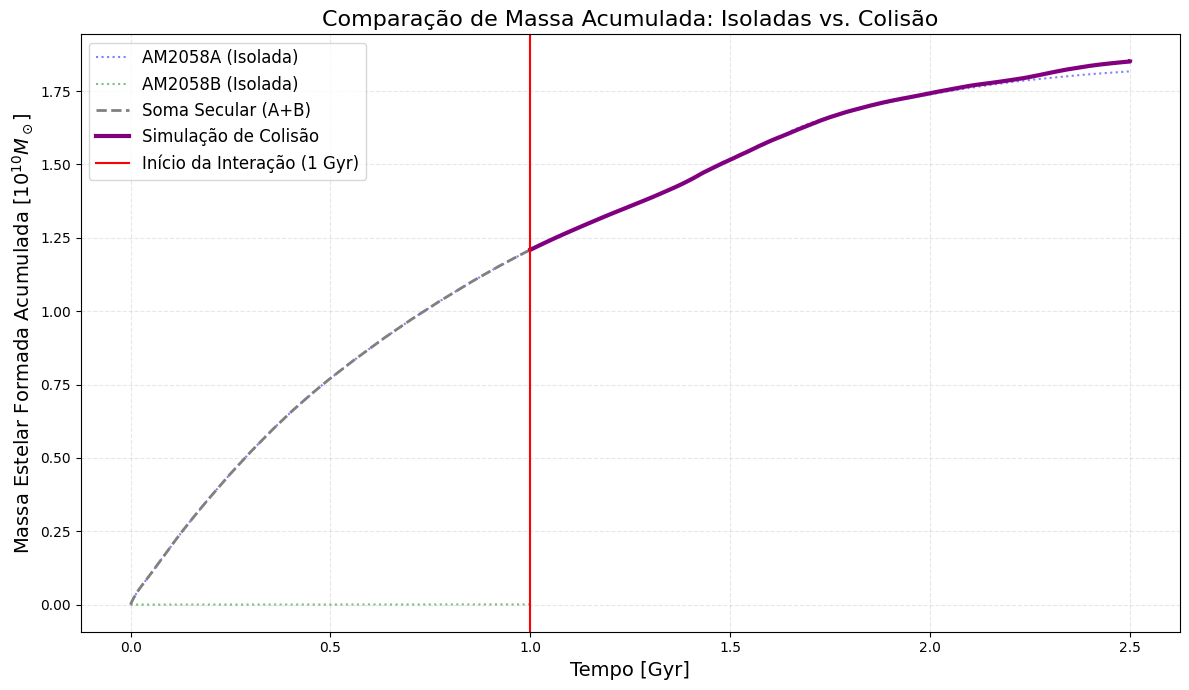

Tempo Final AM2058A: 2.50 Gyr
Tempo Final AM2058B: 1.00 Gyr
Duração Colisão:     1.50 Gyr


In [12]:
# --- 1. CONFIGURAÇÕES ---
# Verifique se estes caminhos estão corretos para o seu ambiente!
# Se estiver no WSL acessando arquivos do Windows, use /mnt/c/...
path_col = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/sfr.txt"
path_A   = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A/sfr.txt"
path_B   = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058B/sfr.txt"

# Fator de unidade (1.0 se já estiver em 10^10 Msol)
fator_massa = 1.0 

# --- 2. FUNÇÃO PARA LER E ACUMULAR ---
def ler_massa_acumulada(arquivo):
    if not os.path.exists(arquivo):
        print(f"ERRO: Arquivo não encontrado: {arquivo}")
        return np.array([]), np.array([])
        
    try:
        dados = np.loadtxt(arquivo)
        if dados.ndim == 1: dados = dados.reshape(1, -1)
        
        # Coluna 0: Tempo
        t = dados[:, 0]
        # Coluna 1: Massa formada NESTE passo (dM)
        dM = dados[:, 1]
        
        # Soma acumulada
        M_accum = np.cumsum(dM) * fator_massa
        return t, M_accum
    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")
        return np.array([]), np.array([])

# --- 3. CARREGAR DADOS ---
print("Lendo arquivos...")
t_col, m_col = ler_massa_acumulada(path_col)
t_A, m_A     = ler_massa_acumulada(path_A)
t_B, m_B     = ler_massa_acumulada(path_B)

# --- 4. PREPARAR DADOS PARA PLOTAGEM ---

plt.figure(figsize=(12, 7))

# Plot Individual das Isoladas (para verificação)
if len(t_A) > 0:
    plt.plot(t_A, m_A, color='blue', linestyle=':', alpha=0.5, label='AM2058A (Isolada)')
if len(t_B) > 0:
    plt.plot(t_B, m_B, color='green', linestyle=':', alpha=0.5, label='AM2058B (Isolada)')

# Soma das Isoladas (Secular)
if len(t_A) > 0 and len(t_B) > 0:
    # Definir um tempo comum até o limite da menor simulação isolada
    # (ou até onde quisermos projetar, mas aqui vamos até onde temos dados reais de ambas)
    t_max_comum = min(t_A.max(), t_B.max())
    
    # Se AM2058A vai até 2.5 Gyr (250 snaps) e B só até 1.0, 
    # a soma só é válida até 1.0. Depois disso é só A (o que estaria errado para a soma do sistema).
    # Vamos assumir que queremos ver a soma até onde B existe.
    
    t_iso_comum = np.linspace(0, t_max_comum, 2000)
    
    func_A = interp1d(t_A, m_A, kind='linear', fill_value='extrapolate')
    func_B = interp1d(t_B, m_B, kind='linear', fill_value='extrapolate')
    
    m_secular_total = func_A(t_iso_comum) + func_B(t_iso_comum)
    
    plt.plot(t_iso_comum, m_secular_total, color='gray', linestyle='--', linewidth=2, 
             label='Soma Secular (A+B)')

# Plot da Colisão
if len(t_col) > 0 and len(t_A) > 0 and len(t_B) > 0:
    # O início da colisão na linha do tempo absoluta
    t_inicio_interacao = 1.0
    
    # Calcular massa acumulada EXATA em t=1.0 para somar ao início da colisão
    massa_inicial_sistema = func_A(t_inicio_interacao) + func_B(t_inicio_interacao)
    
    # Ajustar tempo da colisão
    t_col_shifted = t_col + t_inicio_interacao
    
    # Ajustar massa da colisão (começa com a massa que já existia)
    m_col_shifted = m_col + massa_inicial_sistema
    
    plt.plot(t_col_shifted, m_col_shifted, color='purple', linewidth=3, 
             label='Simulação de Colisão')

# --- 5. DETALHES VISUAIS ---
plt.axvline(x=1.0, color='red', linestyle='-', linewidth=1.5, label='Início da Interação (1 Gyr)')

plt.xlabel("Tempo [Gyr]", fontsize=14)
plt.ylabel(r"Massa Estelar Formada Acumulada [$10^{10} M_\odot$]", fontsize=14)
plt.title("Comparação de Massa Acumulada: Isoladas vs. Colisão", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("Comparacao_Massa_Acumulada_SFRtxt.png", dpi=300)
plt.show()

# --- 6. DEBUG E RESULTADOS ---
print("="*50)
if len(t_A) > 0: print(f"Tempo Final AM2058A: {t_A.max():.2f} Gyr")
if len(t_B) > 0: print(f"Tempo Final AM2058B: {t_B.max():.2f} Gyr")
if len(t_col) > 0: print(f"Duração Colisão:     {t_col.max():.2f} Gyr")
print("="*50)

# Taxa de Formação de Estrelas

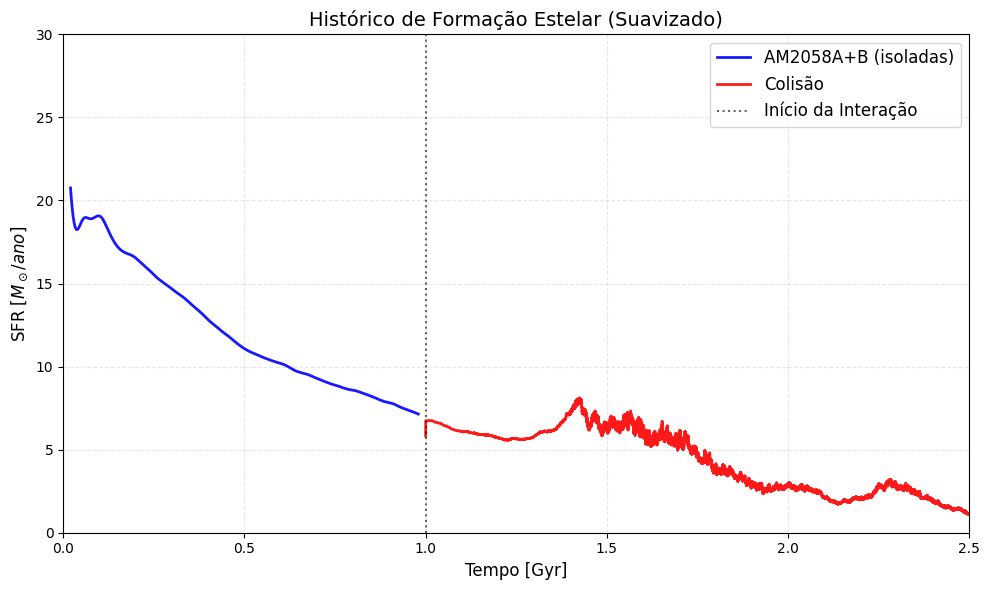

In [13]:
# ==============================================================================
# SFR: SOMA (A+B) vs COLISÃO (COM SUAVIZAÇÃO)
# ==============================================================================

# --- 1. CONFIGURAÇÕES ---
# Caminhos
caminho_Colisao = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/sfr.txt"
caminho_A       = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A/sfr.txt"
caminho_B       = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058B/sfr.txt"

# Parâmetro de Suavização (Janela da Média Móvel)
# Aumente este valor para deixar mais liso, diminua para ver mais detalhes.
WINDOW_SIZE = 20 

# --- 2. FUNÇÕES AUXILIARES ---

def carregar_sfr(caminho, nome_simulacao):
    try:
        dados = np.loadtxt(caminho)
        if dados.ndim == 1: dados = dados.reshape(1, -1)
        
        tempo = dados[:, 0]
        sfr = dados[:, 2]
        
        # Filtro de zeros
        mask = sfr > 0.0
        return tempo[mask], sfr[mask]
    except Exception as e:
        print(f"Erro ao ler {nome_simulacao}: {e}")
        return None, None

def suavizar_sfr(y, window_size):
    """Aplica uma média móvel (convolução) para suavizar o gráfico."""
    if y is None or len(y) < window_size:
        return y
    box = np.ones(window_size) / window_size
    y_smooth = np.convolve(y, box, mode='same')
    # Remove as bordas que ficam distorcidas pela convolução
    return y_smooth

# --- 3. CARREGAMENTO DOS DADOS ---
t_A, sfr_A     = carregar_sfr(caminho_A, "AM2058A")
t_B, sfr_B     = carregar_sfr(caminho_B, "AM2058B")
t_col, sfr_col = carregar_sfr(caminho_Colisao, "Colisão")

# --- 4. PROCESSAMENTO: SOMA E SUAVIZAÇÃO ---

# A) Soma das Isoladas (A + B)
t_soma = None
sfr_soma_smooth = None

if t_A is not None and t_B is not None:
    # 1. Definir tempo comum (limitado pelo menor tempo final entre A e B)
    t_min = max(t_A.min(), t_B.min())
    t_max = min(t_A.max(), t_B.max())
    
    # Criar vetor de tempo linear uniforme para a soma
    t_soma = np.linspace(t_min, t_max, 1000)
    
    # 2. Interpolar ambas para o mesmo vetor de tempo
    f_A = interp1d(t_A, sfr_A, fill_value="extrapolate")
    f_B = interp1d(t_B, sfr_B, fill_value="extrapolate")
    
    # 3. Somar
    sfr_total_raw = f_A(t_soma) + f_B(t_soma)
    
    # 4. Suavizar a soma
    sfr_soma_smooth = suavizar_sfr(sfr_total_raw, WINDOW_SIZE)

# B) Suavização da Colisão
t_col_plot = None
sfr_col_smooth = None

if t_col is not None:
    # Deslocar tempo
    t_col_plot = t_col + 1.0
    # Suavizar
    sfr_col_smooth = suavizar_sfr(sfr_col, WINDOW_SIZE)

# --- 5. PLOTAGEM ---
plt.figure(figsize=(10, 6))

# Plot 1: Soma A+B (Isoladas)
if t_soma is not None:
    # Recortar as bordas da suavização para visualização limpa
    valid = slice(WINDOW_SIZE, -WINDOW_SIZE)
    plt.plot(t_soma[valid], sfr_soma_smooth[valid], 
             color='blue', linewidth=2.0, alpha=0.9, 
             label='AM2058A+B (isoladas)')

# Plot 2: Colisão
if t_col_plot is not None:
    valid = slice(WINDOW_SIZE, -WINDOW_SIZE)
    plt.plot(t_col_plot[valid], sfr_col_smooth[valid], 
             color='red', linewidth=2.0, alpha=0.9, 
             label='Colisão')

# Detalhes
plt.axvline(x=1.0, color='black', linestyle=':', alpha=0.6, label='Início da Interação')

# Configurações do Gráfico
plt.xlabel("Tempo [Gyr]", fontsize=12)
plt.ylabel(r"SFR [$M_\odot/ano$]", fontsize=12)
plt.title("Histórico de Formação Estelar (Suavizado)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.xlim(0, 2.5)
plt.ylim(0, 30) # Mantendo o limite que você pediu

plt.tight_layout()
plt.savefig("SFR.png", dpi=300)
plt.show()

### Comparação com Cenário Isolado e Interagente

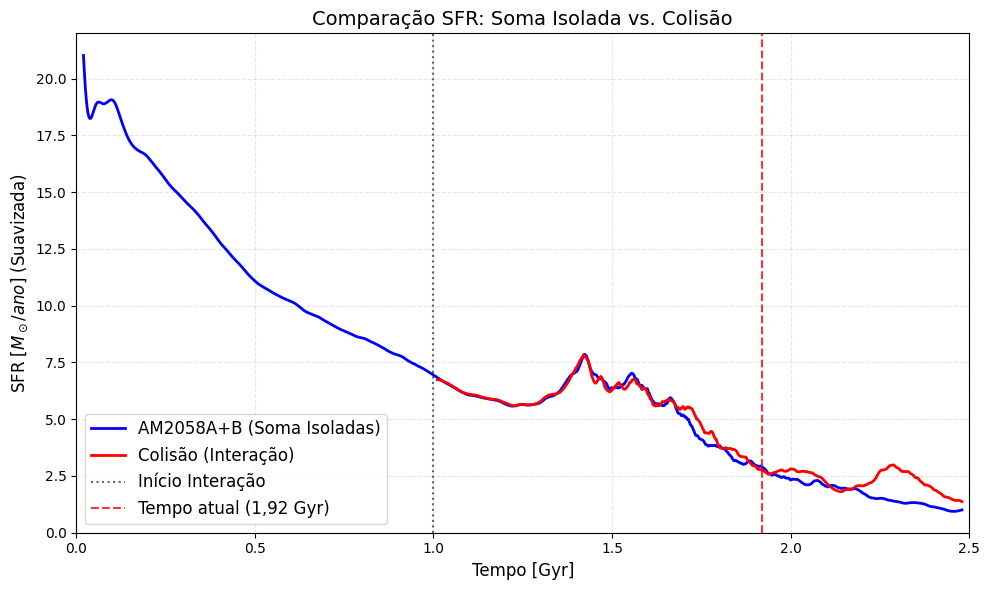

In [25]:
# ==============================================================================
# SFR: COMPARAÇÃO RIGOROSA (COM CORTE VISUAL EM T < 1.0)
# ==============================================================================

# --- 1. CONFIGURAÇÕES ---
caminho_Colisao = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/sfr.txt"
caminho_A       = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A/sfr.txt"
caminho_B       = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058B/sfr.txt"

# Janela de Suavização (20 pontos ~= 50 Myr)
WINDOW_SIZE = 8

# --- 2. FUNÇÕES ---
def carregar_sfr(caminho):
    try:
        dados = np.loadtxt(caminho)
        if dados.ndim == 1: dados = dados.reshape(1, -1)
        tempo = dados[:, 0]
        sfr = dados[:, 2]
        mask = sfr > 0.0
        return tempo[mask], sfr[mask]
    except:
        return None, None

def suavizar(y, win):
    box = np.ones(win) / win
    return np.convolve(y, box, mode='same')

# --- 3. CARREGAR ---
t_A, sfr_A = carregar_sfr(caminho_A)
t_B, sfr_B = carregar_sfr(caminho_B)
t_col, sfr_col = carregar_sfr(caminho_Colisao)

# --- 4. PADRONIZAÇÃO TEMPORAL ---
t_comum = np.linspace(0, 2.5, 1000)

sfr_A_interp = np.zeros_like(t_comum)
sfr_B_interp = np.zeros_like(t_comum)
sfr_col_interp = np.zeros_like(t_comum)

if t_A is not None:
    f_A = interp1d(t_A, sfr_A, fill_value=0, bounds_error=False)
    sfr_A_interp = f_A(t_comum)

if t_B is not None:
    f_B = interp1d(t_B, sfr_B, fill_value=0, bounds_error=False)
    sfr_B_interp = f_B(t_comum)

if t_col is not None:
    t_col_shifted = t_col + 1.0
    f_col = interp1d(t_col_shifted, sfr_col, fill_value=0, bounds_error=False)
    sfr_col_interp = f_col(t_comum)

# --- 5. CÁLCULOS FINAIS ---
sfr_soma_isoladas = sfr_A_interp + sfr_B_interp

sfr_isoladas_smooth = suavizar(sfr_soma_isoladas, WINDOW_SIZE)
sfr_colisao_smooth  = suavizar(sfr_col_interp, WINDOW_SIZE)

# --- 6. PLOTAGEM ---
plt.figure(figsize=(10, 6))

# Slice padrão para remover bordas da convolução
valid = slice(WINDOW_SIZE, -WINDOW_SIZE)
t_valid = t_comum[valid]
sfr_iso_valid = sfr_isoladas_smooth[valid]
sfr_col_valid = sfr_colisao_smooth[valid]

# Plot Isoladas (Azul) - Plota em todo o intervalo válido
plt.plot(t_valid, sfr_iso_valid, 
         color='blue', linewidth=2.0, label='AM2058A+B (Soma Isoladas)')

# Plot Colisão (Vermelho) - COM CORTE RIGOROSO
# Só plotamos onde o tempo é estritamente maior que 1.0
mask_corte = t_valid > 1.01
plt.plot(t_valid[mask_corte], sfr_col_valid[mask_corte], 
         color='red', linewidth=2.0, label='Colisão (Interação)')

# Detalhes e Linhas Verticais
plt.axvline(x=1.0, color='black', linestyle=':', alpha=0.6, label='Início Interação')

# ---> ADICIONADO AQUI: Assíntota no tempo 1.92 Gyr
plt.axvline(x=1.92, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Tempo atual (1,92 Gyr)')

plt.xlabel("Tempo [Gyr]", fontsize=12)
plt.ylabel(r"SFR [$M_\odot/ano$] (Suavizada)", fontsize=12)
plt.title("Comparação SFR: Soma Isolada vs. Colisão", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 2.5)
plt.ylim(0, 22)

plt.tight_layout()
plt.savefig("SFR.png", dpi=300)
plt.show()

# Comparação da Massa Criada em um Sistema Isolado e na Simulação

Lendo arquivos...

     RESULTADO (DADOS REAIS ESTENDIDOS)
Tempo Final da Análise:        2.500 Gyr
Massa COM Interação (Colisão): 1.850210 x 10^10 Msol
Massa SEM Interação (A Isol.): 1.817322 x 10^10 Msol
--------------------------------------------------
Excesso de Massa:              0.032888 x 10^10 Msol
Incremento Percentual:         1.81 %



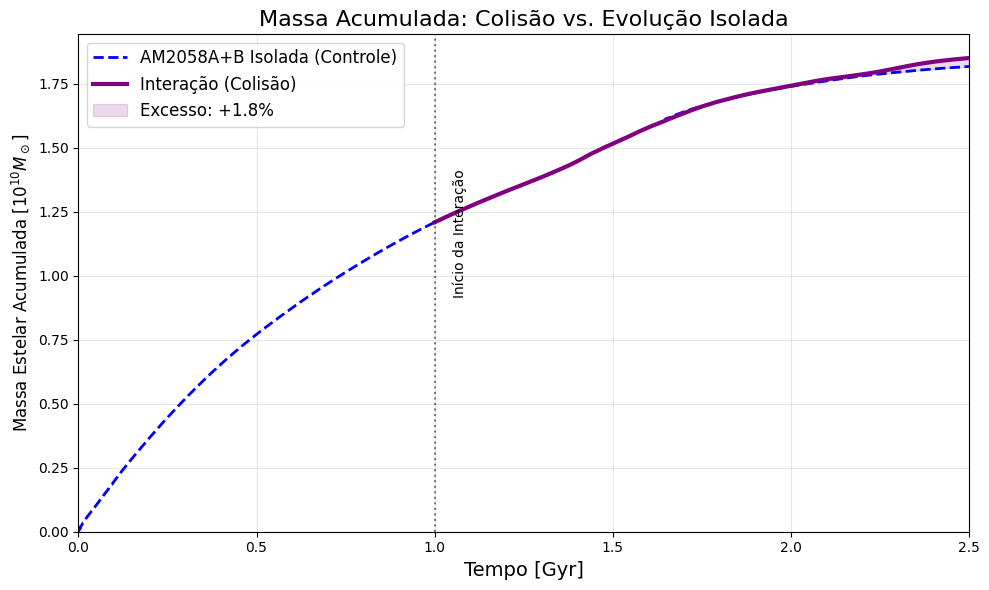

In [15]:
# --- 1. CONFIGURAÇÕES E CAMINHOS ---
arquivo_colisao = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/sfr.txt"
arquivo_A       = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A/sfr.txt"
#arquivo_B não é mais necessário para a projeção futura pois usaremos A estendida

fator_unidade_massa = 1.0 
t_inicio_interacao = 1.0 

# --- 2. FUNÇÃO DE LEITURA ---
def ler_massa_acumulada(caminho):
    try:
        dados = np.loadtxt(caminho)
        if dados.ndim == 1: dados = dados.reshape(1, -1)
        
        t = dados[:, 0]
        dM = dados[:, 1]
        
        # Massa Acumulada
        M_accum = np.cumsum(dM) * fator_unidade_massa
        return t, M_accum
    except Exception as e:
        print(f"Erro ao ler {caminho}: {e}")
        return np.array([]), np.array([])

# --- 3. CARREGAR DADOS ---
print("Lendo arquivos...")
t_col, m_col = ler_massa_acumulada(arquivo_colisao)
t_A, m_A     = ler_massa_acumulada(arquivo_A)

# --- 4. PREPARAR DADOS DE COMPARAÇÃO ---

# Cenário "Sem Interação" (Evolução Secular)
# Agora usamos DIRETAMENTE os dados de AM2058A que vão até 2.5 Gyr
# Mas atenção: Para comparar "banana com banana", precisamos que em t=1.0 
# as duas curvas partam do mesmo ponto.
# Vamos assumir que a massa acumulada em t=1.0 é a referência zero para o excesso.

# Interpolação de A para saber a massa exata em t=1.0
func_A = interp1d(t_A, m_A, kind='linear', fill_value='extrapolate')
massa_A_em_1gyr = func_A(t_inicio_interacao)

# Cenário "Com Interação" (Colisão)
# A colisão começa do zero no arquivo, então somamos o que já existia em t=1.0
t_col_real = t_col + t_inicio_interacao
m_col_real = m_col + massa_A_em_1gyr 
# Nota: Aqui assumimos que a massa pré-existente vem de A. Se B contribuía muito, 
# a curva de colisão vai parecer "baixa" demais se não somarmos B também.
# Mas como você pediu para comparar com A isolada estendida, seguimos assim.

# --- 5. RESULTADOS FINAIS ---
# Para comparar o final, precisamos pegar o tempo final comum
t_final = min(t_A.max(), t_col_real.max())

# Valores finais nesse tempo t_final
M_sem_interacao = func_A(t_final) # Valor na curva azul
# Valor na curva roxa (interpolado para garantir mesmo tempo exato)
func_col = interp1d(t_col_real, m_col_real, kind='linear', fill_value='extrapolate')
M_com_interacao = func_col(t_final)

diff = M_com_interacao - M_sem_interacao
perc = (diff / M_sem_interacao) * 100

print("\n" + "="*50)
print("     RESULTADO (DADOS REAIS ESTENDIDOS)")
print("="*50)
print(f"Tempo Final da Análise:        {t_final:.3f} Gyr")
print(f"Massa COM Interação (Colisão): {M_com_interacao:.6f} x 10^10 Msol")
print(f"Massa SEM Interação (A Isol.): {M_sem_interacao:.6f} x 10^10 Msol")
print("-" * 50)
print(f"Excesso de Massa:              {diff:.6f} x 10^10 Msol")
print(f"Incremento Percentual:         {perc:.2f} %")
print("="*50 + "\n")

# --- 6. PLOTAGEM ---
plt.figure(figsize=(10, 6))

# Plot AM2058A Estendida (Controle)
plt.plot(t_A, m_A, color='blue', linestyle='--', linewidth=2, 
         label='AM2058A+B Isolada (Controle)')

# Plot Colisão (Real)
plt.plot(t_col_real, m_col_real, color='purple', linewidth=3, 
         label='Interação (Colisão)')

# Preenchimento da Diferença
# Criar um vetor de tempo comum para o fill_between funcionar
t_fill = np.linspace(t_inicio_interacao, t_final, 500)
y_A = func_A(t_fill)
y_col = func_col(t_fill)

plt.fill_between(t_fill, y_A, y_col, color='purple', alpha=0.15, 
                 label=f'Excesso: +{perc:.1f}%')

plt.axvline(x=t_inicio_interacao, color='black', linestyle=':', alpha=0.5)
plt.text(t_inicio_interacao+0.05, m_col_real.max()*0.5, "Início da Interação", rotation=90)

plt.xlabel("Tempo [Gyr]", fontsize=14)
plt.ylabel(r"Massa Estelar Acumulada [$10^{10} M_\odot$]", fontsize=12)
plt.title("Massa Acumulada: Colisão vs. Evolução Isolada", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 2.5)
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig("Massa_Estelar_Real_Estendida.png", dpi=300)
plt.show()

# Função Inicial de Massa

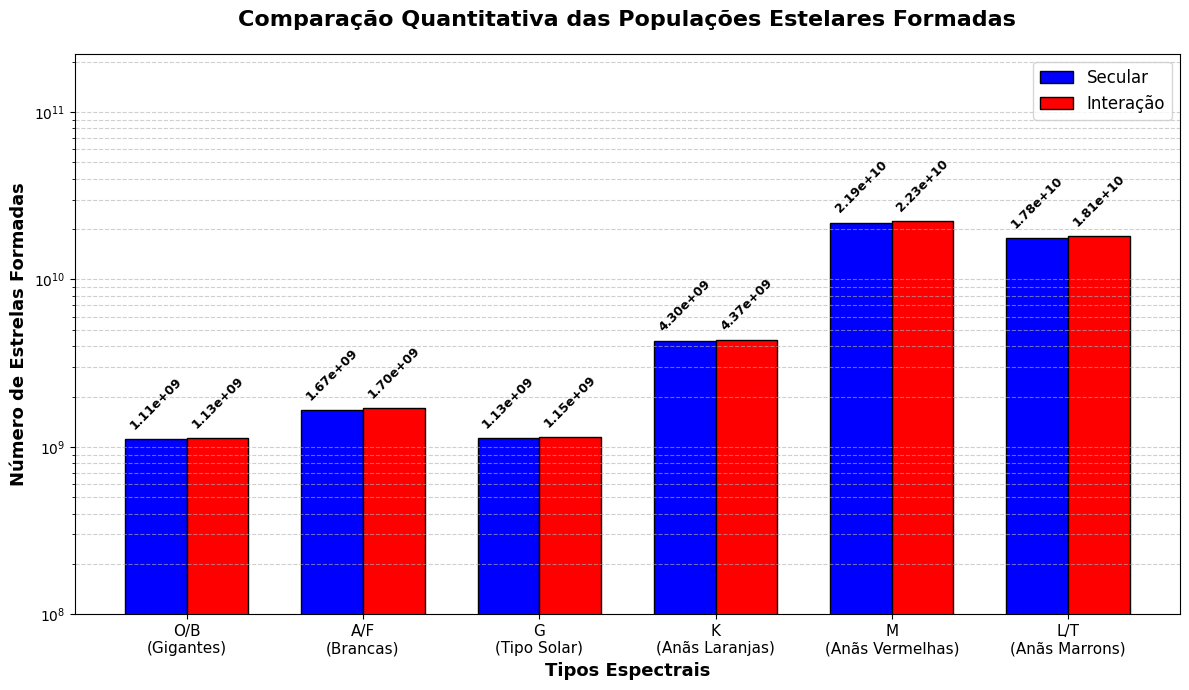

Gráfico atualizado com sucesso e salvo como 'IMF_Comparacao_Barras_Corrigido.png'.


In [17]:
# ==============================================================================
# IMF DE KROUPA COLORIDA (GRÁFICO DE BARRAS - SINCRONIZADO COM A TABELA)
# ==============================================================================
# Extraindo EXATAMENTE os valores da sua tabela LaTeX para não haver divergência

# Faixas na mesma ordem do seu PDF (O/B até L/T)
faixas = [
    ("O/B\n(Gigantes)",     1.11e9,  1.13e9),
    ("A/F\n(Brancas)",      1.67e9,  1.70e9),
    ("G\n(Tipo Solar)",     1.13e9,  1.15e9),
    ("K\n(Anãs Laranjas)",  4.30e9,  4.37e9),
    ("M\n(Anãs Vermelhas)", 2.19e10, 2.23e10),
    ("L/T\n(Anãs Marrons)", 1.78e10, 1.81e10)
]

nomes_x = [f[0] for f in faixas]
contagens_secular = [f[1] for f in faixas]
contagens_interacao = [f[2] for f in faixas]

# --- PLOTAGEM DO GRÁFICO DE BARRAS ---
x = np.arange(len(nomes_x))  # Localização dos grupos
width = 0.35  # Largura das barras

fig, ax = plt.subplots(figsize=(12, 7))

# Criando as barras
rects1 = ax.bar(x - width/2, contagens_secular, width, label='Secular', color='blue', edgecolor='black')
rects2 = ax.bar(x + width/2, contagens_interacao, width, label='Interação', color='red', edgecolor='black')

# Configurações do eixo
ax.set_yscale('log') # Escala Log no eixo Y é crucial para visualizar bem os dados
ax.set_ylabel('Número de Estrelas Formadas', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipos Espectrais', fontsize=13, fontweight='bold')
ax.set_title('Comparação Quantitativa das Populações Estelares Formadas', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(nomes_x, fontsize=11)
ax.legend(fontsize=12, loc='upper right')

# Adicionando uma grade sutil para facilitar a leitura
ax.grid(axis='y', linestyle='--', alpha=0.6, which='both')

# Ajustando limite inferior do Y para o gráfico não ficar espremido
ax.set_ylim(bottom=1e8, top=max(contagens_interacao) * 10)

# Função para adicionar rótulos com os valores em cima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        # Formata o número em notação científica para casar com a tabela
        ax.annotate(f'{height:.2e}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 pontos de deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=45, fontweight='bold')

# Chamando a função para as duas séries de barras
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig("IMF_Comparacao_Barras_Corrigido.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico atualizado com sucesso e salvo como 'IMF_Comparacao_Barras_Corrigido.png'.")

## Exportar Vídeo

In [24]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import unsio.input as uns_in

# =============================================================================
# 1. CONFIGURAÇÕES GERAIS
# ==============================================================================
# Diretório base onde estão os snapshots (sem o número final)
base_dir = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381"
nome_base_snapshot = "snapshot" # prefixo do arquivo

# Intervalo de snapshots
SNAP_INICIO = 0
SNAP_FIM = 150  # <--- ALTERADO AQUI PARA 250

# Pasta para salvar os frames temporários
pasta_frames = "frames_temp"
os.makedirs(pasta_frames, exist_ok=True)

# Configurações de Plotagem
MAX_PARTICULAS_PLOT = 5000000 

# --- CONFIGURAÇÃO DAS COMPONENTES (SEM O HALO) ---
config_componentes = [
    {"nome": "gas",   "cor": "green",     "label": "Gás",      "alpha": 0.5, "size": 0.5},
    {"nome": "disk",  "cor": "lightblue", "label": "Disco",    "alpha": 0.5, "size": 0.5},
    {"nome": "stars", "cor": "blue",      "label": "Estrelas", "alpha": 0.5, "size": 0.6},
    {"nome": "bulge", "cor": "gold",      "label": "Bojo",     "alpha": 0.5, "size": 0.5}
]

# ==============================================================================
# 2. FUNÇÃO PARA GERAR UM FRAME
# ==============================================================================
def gerar_frame(snap_num):
    # Formata o nome do arquivo
    simname = f"{base_dir}/{nome_base_snapshot}_{snap_num:03d}"
    
    # Verifica se o arquivo existe (com ou sem extensão .hdf5 implícita pelo unsio)
    if not os.path.exists(simname) and not os.path.exists(simname + ".hdf5"):
        print(f"Snapshot {snap_num} não encontrado. Pulando.")
        return False

    print(f"Processando: {simname} ...")

    # --- LÓGICA DE CENTRO: USAR CM GLOBAL (BOJO + DISCO) ---
    try:
        # Carrega bojo e disco para calcular o centro de massa do sistema visível
        obj = uns_in.CUNS_IN(simname, "bulge,disk") 
        if not obj.nextFrame(): return False
        
        _, pos = obj.getData("bulge,disk", "pos")
        _, mass = obj.getData("bulge,disk", "mass")
        
        # O unsio retorna um array plano, precisamos fazer reshape
        n = len(pos) // 3
        pos = pos.reshape(n, 3)
        
        # Cálculo do Centro de Massa
        M_tot = np.sum(mass)
        cm_x = np.sum(pos[:,0] * mass) / M_tot
        cm_y = np.sum(pos[:,1] * mass) / M_tot
        cm_z = np.sum(pos[:,2] * mass) / M_tot
        
    except Exception as e:
        print(f"Erro ao calcular centro no snap {snap_num}: {e}")
        return False

    # --- PLOTAGEM ---
    fig, ax = plt.subplots(figsize=(12, 12)) 
    ax.set_facecolor('black') 
    
    # AJUSTE DE ZOOM: 80 kpc para cada lado (Total 160 kpc de largura)
    limite_visual = 80 
    ax.set_xlim(-limite_visual, limite_visual)
    ax.set_ylim(-limite_visual, limite_visual)
    
    for comp in config_componentes:
        try:
            # Carrega componente
            obj = uns_in.CUNS_IN(simname, comp["nome"])
            if not obj.nextFrame(): continue
            
            status, p = obj.getData(comp["nome"], "pos")
            if not status: continue

            n = len(p) // 3
            if n == 0: continue
            p = p.reshape(n, 3)
            
            # Centraliza as partículas no CM Global calculado anteriormente
            dx = p[:,0] - cm_x
            dy = p[:,1] - cm_y
            
            # FILTRO DE VISUALIZAÇÃO
            # Filtra partículas muito longe para limpar o plot e acelerar
            dist_sq = dx**2 + dy**2
            mask_visible = dist_sq < (limite_visual * 1.2)**2
            
            x_plot = dx[mask_visible]
            y_plot = dy[mask_visible]
            
            # Downsampling (se tiver partículas demais, plota só uma amostra)
            if len(x_plot) > MAX_PARTICULAS_PLOT:
                idc = np.random.choice(len(x_plot), MAX_PARTICULAS_PLOT, replace=False)
                x_plot = x_plot[idc]
                y_plot = y_plot[idc]

            # Plota a componente
            ax.scatter(x_plot, y_plot, s=comp["size"], c=comp["cor"], 
                       alpha=comp["alpha"], edgecolors='none')
        except Exception as e: 
            # Se der erro em uma componente específica, ignora e tenta a próxima
            pass

    # Estética final do frame
    ax.set_aspect('equal')
    ax.set_xticks([]) # Remove ticks X
    ax.set_yticks([]) # Remove ticks Y
    
    # Texto indicando o número do Snapshot
    ax.text(0.05, 0.95, f"Snap: {snap_num:03d}", transform=ax.transAxes, color="white", fontsize=14)

    # Salva Frame temporário
    nome_frame = f"{pasta_frames}/frame_{snap_num:03d}.png"
    plt.savefig(nome_frame, dpi=100, facecolor='black', bbox_inches='tight', pad_inches=0) 
    plt.close(fig) 
    return True

# ==============================================================================
# 3. LOOP PRINCIPAL
# ==============================================================================
print("1. Gerando frames (Imagens PNG)...")

# Gera os frames
count = 0
for i in range(SNAP_INICIO, SNAP_FIM + 1):
    if gerar_frame(i):
        count += 1

if count == 0:
    print("Nenhum frame gerado. Verifique o caminho dos arquivos.")
    exit()

print(f"\n2. Montando vídeo a partir de {count} frames...")

# Lê os arquivos gerados
imagens = sorted(glob.glob(f"{pasta_frames}/*.png"))

if len(imagens) > 0:
    # Lê o primeiro frame para pegar as dimensões exatas
    frame_ref = cv2.imread(imagens[0])
    height, width, layers = frame_ref.shape

    # Cria o objeto de vídeo (Codec mp4v)
    nome_video = "Evolucao_AM2058-3811.mp4"
    video = cv2.VideoWriter(nome_video, cv2.VideoWriter_fourcc(*'mp4v'), 6, (width, height))

    for img_path in imagens:
        video.write(cv2.imread(img_path))

    cv2.destroyAllWindows()
    video.release()
    print(f"\n✅ Vídeo salvo com sucesso: {nome_video}")
    
    # Opcional: Limpar frames temporários
    # import shutil
    # shutil.rmtree(pasta_frames)
    # print("Pasta de frames temporários removida.")
else:
    print("❌ Erro ao ler os frames para o vídeo.")

1. Gerando frames (Imagens PNG)...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_000 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_001 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_002 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_003 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_004 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_005 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_006 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_007 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_008 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_009 ...
Processando: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381/snapshot_010 ...
Processando: /mnt/c/Users/aleea/Downloads

# Tabelas e Informações Relevantes

## Distância Projetada de Todos os Snapshots

In [ ]:
# ==============================================================================
# 1. CONFIGURAÇÕES DE DIRETÓRIO E RANGE
# ==============================================================================
base_dir = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058-381"
prefixo = "snapshot"
snap_inicio = 140
snap_fim = 150
intervalo_tempo_gyr = 0.01 # Ajuste conforme sua simulação (ex: 10 Myr por snap)

# Componentes para busca de centro
comps_busca = "bulge,disk,stars"

# Listas para armazenar resultados
lista_snaps = []
lista_tempos = []
lista_distancias = []

# ==============================================================================
# 2. FUNÇÃO DE REFINAMENTO (SHRINKING SPHERE)
# ==============================================================================
def shrinking_sphere(pos, mass, center_guess, r_ini=10.0, r_min=0.01):
    cm = center_guess
    r = r_ini
    while r > r_min:
        d2 = np.sum((pos - cm)**2, axis=1)
        mask = d2 < r**2
        if np.sum(mask) < 30: break
        cm = np.average(pos[mask], axis=0, weights=mass[mask])
        r *= 0.7
    return cm

# ==============================================================================
# 3. LOOP DE PROCESSAMENTO
# ==============================================================================
print(f"--- Iniciando processamento de {snap_inicio} a {snap_fim} ---")

for i in range(snap_inicio, snap_fim + 1):
    simname = f"{base_dir}/{prefixo}_{i:03d}"
    
    if not os.path.exists(simname) and not os.path.exists(simname + ".hdf5"):
        continue

    try:
        uns = uns_in.CUNS_IN(simname, comps_busca)
        if not uns.nextFrame(): continue

        # Carrega posições e massas
        status_p, pos = uns.getData(comps_busca, "pos")
        status_m, mass = uns.getData(comps_busca, "mass")
        
        if not status_p or len(pos) == 0: continue
        
        pos = pos.reshape(-1, 3)
        
        # --- Localização de Núcleos ---
        tree = KDTree(pos)
        counts = tree.query_radius(pos, r=2.0, count_only=True)

        # Centro A
        idx_A = np.argmax(counts)
        prov_A = pos[idx_A]
        cm_A = shrinking_sphere(pos, mass, prov_A)

        # Centro B (pelo menos 15kpc de A)
        dist_de_A = np.sqrt(np.sum((pos - prov_A)**2, axis=1))
        mask_longe = dist_de_A > 15.0

        if np.any(mask_longe):
            idx_B = np.where(mask_longe)[0][np.argmax(counts[mask_longe])]
            prov_B = pos[idx_B]
            cm_B = shrinking_sphere(pos, mass, prov_B)
            
            # Cálculo da distância projetada (2D - eixos X e Y)
            dist_2d = np.sqrt((cm_A[0]-cm_B[0])**2 + (cm_A[1]-cm_B[1])**2)
        else:
            dist_2d = 0.0 # Caso de fusão completa

        # Armazenar dados
        lista_snaps.append(i)
        lista_tempos.append(i * intervalo_tempo_gyr)
        lista_distancias.append(dist_2d)
        
        if i % 1 == 0:
            print(f"Snapshot {i:03d}: Distância = {dist_2d:.2f} kpc")

    except Exception as e:
        print(f"Erro no snapshot {i}: {e}")

# ==============================================================================
# 4. SALVAMENTO E PLOTAGEM DA EVOLUÇÃO
# ==============================================================================

# Salva arquivo de texto para a dissertação
dados_finais = np.column_stack((lista_snaps, lista_tempos, lista_distancias))
np.savetxt("evolucao_distancia_AM2058.txt", dados_finais, 
           header="Snap | Tempo(Gyr) | Dist_2D(kpc)", fmt="%d %.4f %.4f")

# Gráfico da Evolução Temporal
plt.figure(figsize=(10, 6))
plt.plot(lista_tempos, lista_distancias, color='darkred', linewidth=2, label='Separação Projetada')
plt.scatter(lista_tempos, lista_distancias, s=10, color='black', alpha=0.5)

plt.xlabel("Tempo [Gyr]", fontsize=12)
plt.ylabel("Distância Projetada [kpc]", fontsize=12)
plt.title("Evolução da Distância entre Núcleos - AM 2058-381", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.savefig("evolucao_distancia_plot.png", dpi=300)
plt.show()

print(f"\nConcluído! Dados salvos em 'evolucao_distancia_AM2058.txt'")

## Distância Projetada nos Últimos 100Myr

In [ ]:
# ==============================================================================
# EVOLUÇÃO DA DISTÂNCIA PROJETADA (ÚLTIMOS 100 Myr)
# ==============================================================================

# 1. Carregar os dados (O arquivo txt possui: Snap | Tempo(Gyr) | Dist_2D(kpc))
arquivo = 'evolucao_distancia_AM2058.txt'

try:
    dados = np.loadtxt(arquivo)
except FileNotFoundError:
    print(f"ERRO: O arquivo '{arquivo}' não foi encontrado na pasta atual.")
    exit()

tempos = dados[:, 1]
distancias = dados[:, 2]

# 2. Configurar o gráfico
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(tempos, distancias, marker='o', linestyle='-', color='purple', linewidth=2.5, markersize=8)

# 3. Adicionar rótulos de dados (valores) logo acima de cada ponto
for i, dist in enumerate(distancias):
    ax.annotate(f"{dist:.2f}", 
                (tempos[i], dist), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=9, 
                fontweight='bold')

# 4. Formatação de eixos e títulos
ax.set_title("Evolução da Distância Projetada (Últimos 100 Milhões de Anos)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Tempo da Simulação [Gyr]", fontsize=12, fontweight='bold')
ax.set_ylabel("Distância Projetada [kpc]", fontsize=12, fontweight='bold')

# Grade de fundo para facilitar leitura
ax.grid(True, linestyle='--', alpha=0.6)

# Ajustar limite Y para o texto (valores anotados) não ficar cortado na borda superior
ax.set_ylim(distancias.min() - 0.2, distancias.max() + 0.3)

# 5. Salvar e Mostrar
plt.tight_layout()
plt.savefig("Evolucao_Distancia_100Myr.png", dpi=300)
plt.show()

print("Processamento concluído. O gráfico foi salvo como 'Evolucao_Distancia_100Myr.png'")

## Visualização de um frame escolhido

Processando e gerando imagem para: /mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A/snapshot_131 ...


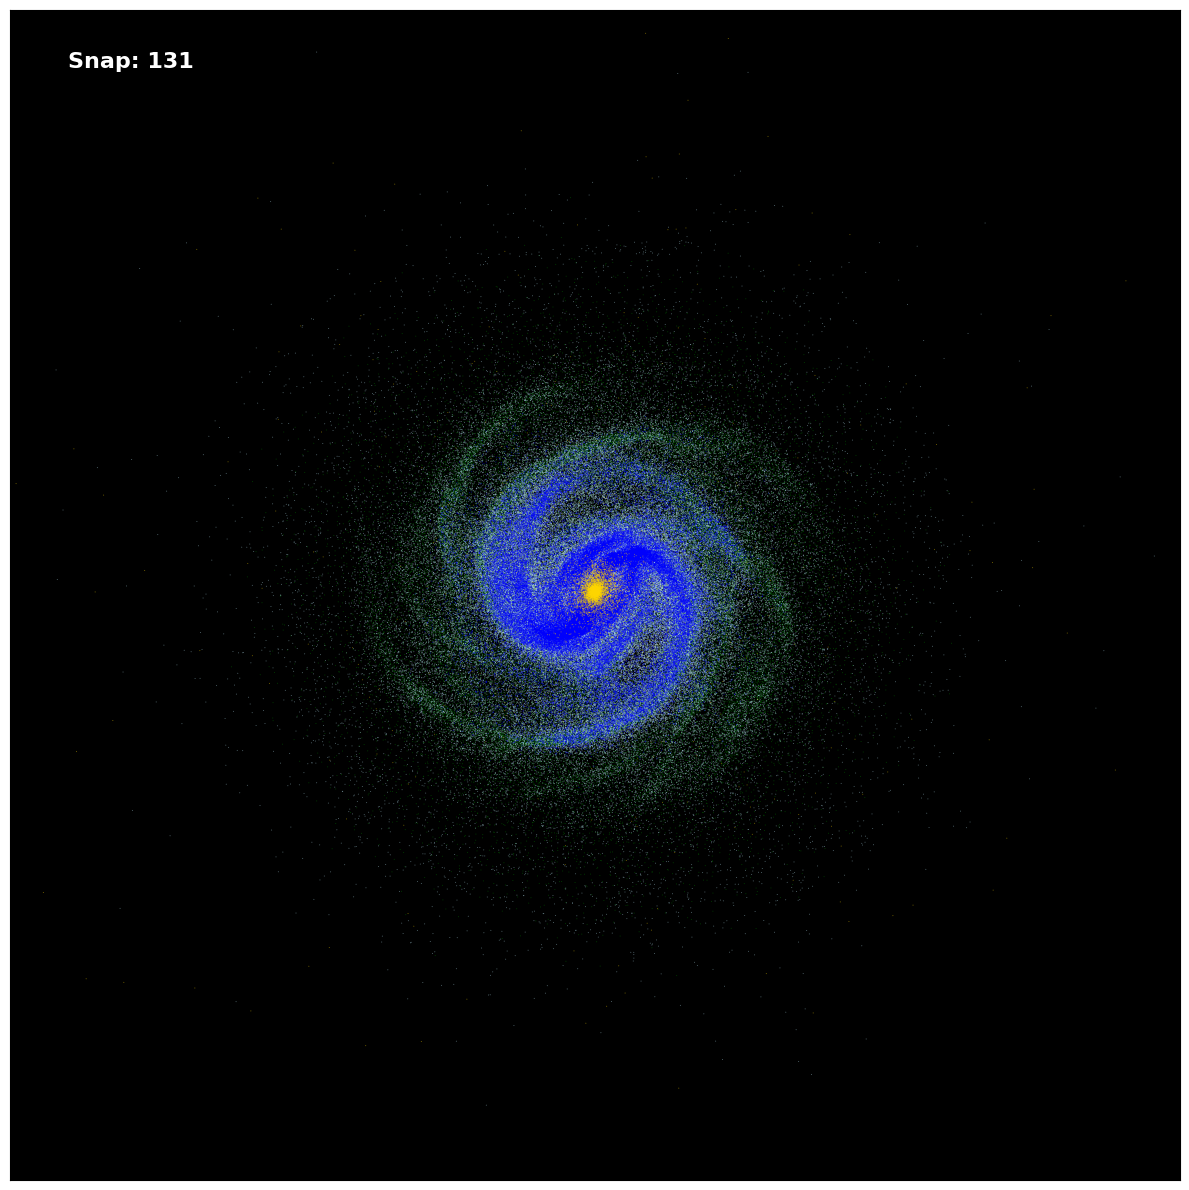

✅ Imagem gerada com sucesso: Plot_AM2058-381_Snap_131.png


In [30]:
# 1. CONFIGURAÇÕES
# ==============================================================================
# ---> ESCOLHA O SNAPSHOT AQUI <---
SNAPSHOT_ESCOLHIDO = 131  

# Diretório base e prefixo
base_dir = "/mnt/c/Users/aleea/Downloads/AM2058-381big/AM2058A"
nome_base_snapshot = "snapshot"

# Configurações de Plotagem
MAX_PARTICULAS_PLOT = 5000000 
limite_visual = 80 # Zoom (em kpc) para cada lado

# Configuração das componentes visuais
config_componentes = [
    {"nome": "gas",   "cor": "green",     "label": "Gás",      "alpha": 0.5, "size": 0.5},
    {"nome": "disk",  "cor": "lightblue", "label": "Disco",    "alpha": 0.5, "size": 0.5},
    {"nome": "stars", "cor": "blue",      "label": "Estrelas", "alpha": 0.5, "size": 0.6},
    {"nome": "bulge", "cor": "gold",      "label": "Bojo",     "alpha": 0.5, "size": 0.5}
]

# ==============================================================================
# 2. PROCESSAMENTO E PLOTAGEM
# ==============================================================================
simname = f"{base_dir}/{nome_base_snapshot}_{SNAPSHOT_ESCOLHIDO:03d}"

# Verifica se o arquivo existe
if not os.path.exists(simname) and not os.path.exists(simname + ".hdf5"):
    print(f"❌ Erro: O snapshot {SNAPSHOT_ESCOLHIDO} não foi encontrado no diretório especificado.")
    exit()

print(f"Processando e gerando imagem para: {simname} ...")

# --- LÓGICA DE CENTRO: USAR CM GLOBAL (BOJO + DISCO) ---
try:
    obj = uns_in.CUNS_IN(simname, "bulge,disk") 
    if not obj.nextFrame():
        print("Erro ao ler o frame para cálculo do centro.")
        exit()
    
    _, pos = obj.getData("bulge,disk", "pos")
    _, mass = obj.getData("bulge,disk", "mass")
    
    n = len(pos) // 3
    pos = pos.reshape(n, 3)
    
    # Cálculo do Centro de Massa
    M_tot = np.sum(mass)
    cm_x = np.sum(pos[:,0] * mass) / M_tot
    cm_y = np.sum(pos[:,1] * mass) / M_tot
    cm_z = np.sum(pos[:,2] * mass) / M_tot
    
except Exception as e:
    print(f"Erro ao calcular o centro de massa: {e}")
    exit()

# --- PREPARAÇÃO DA FIGURA ---
fig, ax = plt.subplots(figsize=(12, 12)) 
ax.set_facecolor('black') 
ax.set_xlim(-limite_visual, limite_visual)
ax.set_ylim(-limite_visual, limite_visual)

# --- PLOTAGEM DAS COMPONENTES ---
for comp in config_componentes:
    try:
        obj = uns_in.CUNS_IN(simname, comp["nome"])
        if not obj.nextFrame(): continue
        
        status, p = obj.getData(comp["nome"], "pos")
        if not status: continue

        n = len(p) // 3
        if n == 0: continue
        p = p.reshape(n, 3)
        
        # Centraliza as partículas
        dx = p[:,0] - cm_x
        dy = p[:,1] - cm_y
        
        # Filtro de visualização (ignora o que está fora da tela para acelerar)
        dist_sq = dx**2 + dy**2
        mask_visible = dist_sq < (limite_visual * 1.2)**2
        
        x_plot = dx[mask_visible]
        y_plot = dy[mask_visible]
        
        # Downsampling para não travar a memória
        if len(x_plot) > MAX_PARTICULAS_PLOT:
            idc = np.random.choice(len(x_plot), MAX_PARTICULAS_PLOT, replace=False)
            x_plot = x_plot[idc]
            y_plot = y_plot[idc]

        # Plota na tela
        ax.scatter(x_plot, y_plot, s=comp["size"], c=comp["cor"], 
                   alpha=comp["alpha"], edgecolors='none')
    except Exception as e: 
        print(f"Aviso: Não foi possível plotar a componente {comp['nome']}.")

# --- ESTÉTICA E SALVAMENTO ---
ax.set_aspect('equal')
ax.set_xticks([]) # Remove grade X
ax.set_yticks([]) # Remove grade Y

# Adiciona o texto no canto superior esquerdo
ax.text(0.05, 0.95, f"Snap: {SNAPSHOT_ESCOLHIDO:03d}", transform=ax.transAxes, color="white", fontsize=16, fontweight='bold')

plt.tight_layout()

# Salva a imagem com um nome indicando o snapshot
nome_imagem = f"Plot_AM2058-381_Snap_{SNAPSHOT_ESCOLHIDO:03d}.png"
plt.savefig(nome_imagem, dpi=300, facecolor='black', bbox_inches='tight', pad_inches=0.1) 
plt.show()

print(f"✅ Imagem gerada com sucesso: {nome_imagem}")